# Capstone Project (Health Care Dataset)

## **Business Problem:**

We all know that Health care is very important domain in the market. It is directly linked with the life of the individual; hence we have to be always be proactive in this particular domain. Money plays a major role in this domain, because sometime treatment becomes super costly and if any individual is not covered under the insurance then it will become a pretty tough financial situation for that individual. The companies in the medical insurance also want to reduce their risk by optimizing the insurance cost, because we all know a healthy body is in the hand of the individual only. If individual eat healthy and do proper exercise the chance of getting ill is drastically reduced.

### **Goal & Objective:**

The objective of this exercise is to build a model, using data that provide the optimum insurance cost for an individual. You have to use the health and habit related parameters for the estimated cost of insurance.

### **Data dictionary:**
- **applicant_id:** Applicant unique ID
- **years_of_insurance_with_us:** Since how many years customer is taking policy from the same company only
- **regular_checkup_lasy_year:** Number of times customers has done the regular health check up in last one year
- **adventure_sports:** Customer is involved with adventure sports like climbing, diving etc.
- **Occupation:** Occupation of the customer.
- **visited_doctor_last_1_year:** Number of times customer has visited doctor in last one year
- **cholesterol_level:** Cholesterol level of the customers while applying for insurance
- **daily_avg_steps:** Average daily steps walked by customers age Age of the customer
- **heart_decs_history:** Any past heart diseases
- **other_major_decs_history:** Any past major diseases apart from heart like any operation
- **Gender:** Gender of the customer
- **avg_glucose_level:** Average glucose level of the customer while applying the insurance
- **bmi:** BMI of the customer while applying the insurance
- **smoking_status:** Smoking status of the customer
- **Year_last_admitted:** When customer have been admitted in the hospital last time
- **Location:** Location of the hospital
- **weight:** Weight of the customer
- **covered_by_any_other_co:** mpany Customer is covered from any other insurance company
- **Alcohol:** Alcohol consumption status of the customer
- **exercise:** Regular exercise status of the customer
- **weight_change_in_last_one_year:** How much variation has been seen in the weight of the customer in last year
- **fat_percentage:** Fat percentage of the customer while applying the insurance
- **insurance_cost:** Total Insurance cost


In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# libaries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Library to split data
from sklearn.model_selection import GridSearchCV, train_test_split


# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# For Classification
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, roc_auc_score

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn import metrics

#For Regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor,RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn import metrics

import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

#To install xgboost library use - !pip install xgboost
from xgboost import XGBClassifier


# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Loading Data

In [2]:
# Loading the dataset - sheet_name parameter is used if there are multiple tabs in the excel file.
from google.colab import drive
drive.mount('/content/drive/') #/Colab_notebooks/Python_Files

Data = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Capstone Health Care Project/Data.csv")

Mounted at /content/drive/


In [3]:
# copying data to another variable to avoid any changes to original data
df = Data.copy()

## Overview of the data

In [4]:
df.head()

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,...,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,...,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,...,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,...,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,...,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,...,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616


In [5]:
df.tail()

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,...,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
24995,29995,3,0,0,Salried,4,225 to 250,5614,22,0,...,smokes,2000.0,Kanpur,79,Y,Rare,Moderate,4,40,39488
24996,29996,6,0,0,Business,4,200 to 225,4719,58,0,...,never smoked,2009.0,Kanpur,66,N,Rare,Moderate,2,28,14808
24997,29997,7,0,1,Student,2,150 to 175,5624,34,0,...,Unknown,NaN,Bhubaneswar,76,N,Rare,Moderate,1,35,33318
24998,29998,1,0,0,Salried,2,225 to 250,10777,27,0,...,Unknown,NaN,Surat,74,N,Rare,Moderate,0,40,30850
24999,29999,8,2,0,Business,4,150 to 175,5882,22,1,...,formerly smoked,2014.0,Chennai,57,N,No,No,4,21,6170


In [6]:
df.shape

(25000, 24)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   applicant_id                    25000 non-null  int64  
 1   years_of_insurance_with_us      25000 non-null  int64  
 2   regular_checkup_lasy_year       25000 non-null  int64  
 3   adventure_sports                25000 non-null  int64  
 4   Occupation                      25000 non-null  object 
 5   visited_doctor_last_1_year      25000 non-null  int64  
 6   cholesterol_level               25000 non-null  object 
 7   daily_avg_steps                 25000 non-null  int64  
 8   age                             25000 non-null  int64  
 9   heart_decs_history              25000 non-null  int64  
 10  other_major_decs_history        25000 non-null  int64  
 11  Gender                          25000 non-null  object 
 12  avg_glucose_level               

- The dataset consists of 8 categorical columns and 16 numerical columns.
- Missing values are present in the `bmi` and `Year_last_admitted` columns.

Converting object-type columns to the category data type helps reduce memory usage.

In [8]:
cols = df.select_dtypes(['object'])
cols.columns

Index(['Occupation', 'cholesterol_level', 'Gender', 'smoking_status',
       'Location', 'covered_by_any_other_company', 'Alcohol', 'exercise'],
      dtype='object')

In [9]:
for i in cols.columns:
    df[i] = df[i].astype('category')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   applicant_id                    25000 non-null  int64   
 1   years_of_insurance_with_us      25000 non-null  int64   
 2   regular_checkup_lasy_year       25000 non-null  int64   
 3   adventure_sports                25000 non-null  int64   
 4   Occupation                      25000 non-null  category
 5   visited_doctor_last_1_year      25000 non-null  int64   
 6   cholesterol_level               25000 non-null  category
 7   daily_avg_steps                 25000 non-null  int64   
 8   age                             25000 non-null  int64   
 9   heart_decs_history              25000 non-null  int64   
 10  other_major_decs_history        25000 non-null  int64   
 11  Gender                          25000 non-null  category
 12  avg_glucose_level 

```We can see that the memory usage has decreased from 4.6+ MB to 3.2 MB, this technique is generally useful for bigger datasets.```

**Checking for duplicate values**

In [11]:
df.duplicated().sum()

np.int64(0)

- There are no duplicate values in the dataset.



**Checking for missing values**

In [12]:
df.isnull().sum()

,0
applicant_id,0
years_of_insurance_with_us,0
regular_checkup_lasy_year,0
adventure_sports,0
Occupation,0
visited_doctor_last_1_year,0
cholesterol_level,0
daily_avg_steps,0
age,0
heart_decs_history,0


- There are missing values in the columns `bmi` and `Year_last_admitted` of the dataset.

**Statistical summary**

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
applicant_id,25000.0,17499.500000,7217.022701,5000.0,11249.75,17499.5,23749.25,29999.0
years_of_insurance_with_us,25000.0,4.089040,2.606612,0.0,2.00,4.0,6.00,8.0
regular_checkup_lasy_year,25000.0,0.773680,1.199449,0.0,0.00,0.0,1.00,5.0
adventure_sports,25000.0,0.081720,0.273943,0.0,0.00,0.0,0.00,1.0
visited_doctor_last_1_year,25000.0,3.104200,1.141663,0.0,2.00,3.0,4.00,12.0
daily_avg_steps,25000.0,5215.889320,1053.179748,2034.0,4543.00,5089.0,5730.00,11255.0
age,25000.0,44.918320,16.107492,16.0,31.00,45.0,59.00,74.0
heart_decs_history,25000.0,0.054640,0.227281,0.0,0.00,0.0,0.00,1.0
other_major_decs_history,25000.0,0.098160,0.297537,0.0,0.00,0.0,0.00,1.0
avg_glucose_level,25000.0,167.530000,62.729712,57.0,113.00,168.0,222.00,277.0


- `applicant_id` is an ID variable and not useful for modelling. Hence, we have removed in greeding method.
- `adventure_sports`, `heart_decs_history`, `other_major_decs_history` column has 75% of the data to be zero.
- `regular_checkup_last_year` column has 50% of the data to be zero.
- `Visited_doctor_last_1_year`, `bmi`, `regular_checkup_last_year`, `average_daily_steps` seems to have outliers.

In [14]:
df.describe(include=['category']).T

,count,unique,top,freq
Occupation,25000,3,Student,10169
cholesterol_level,25000,5,150 to 175,8763
Gender,25000,2,Male,16422
smoking_status,25000,4,never smoked,9249
Location,25000,15,Bangalore,1742
covered_by_any_other_company,25000,2,N,17418
Alcohol,25000,3,Rare,13752
exercise,25000,3,Moderate,14638


- Top region of individual is Bangalore.
- Top occupation found to be student.
- Male individuals are more compared to female.

**Find out unique values in each categorical column**

In [15]:
df['Occupation'].unique()

['Salried', 'Student', 'Business']
Categories (3, object): ['Business', 'Salried', 'Student']

In [16]:
df['cholesterol_level'].unique()

['125 to 150', '150 to 175', '200 to 225', '175 to 200', '225 to 250']
Categories (5, object): ['125 to 150', '150 to 175', '175 to 200', '200 to 225', '225 to 250']

In [17]:
df['Gender'].unique()

['Male', 'Female']
Categories (2, object): ['Female', 'Male']

In [18]:
df['smoking_status'].unique()

['Unknown', 'formerly smoked', 'never smoked', 'smokes']
Categories (4, object): ['Unknown', 'formerly smoked', 'never smoked', 'smokes']

In [19]:
df['Location'].unique()

['Chennai', 'Jaipur', 'Bangalore', 'Bhubaneswar', 'Guwahati', ..., 'Mangalore', 'Kolkata', 'Delhi', 'Ahmedabad', 'Lucknow']
Length: 15
Categories (15, object): ['Ahmedabad', 'Bangalore', 'Bhubaneswar', 'Chennai', ..., 'Mumbai', 'Nagpur',
                          'Pune', 'Surat']

In [20]:
df['covered_by_any_other_company'].unique()

['N', 'Y']
Categories (2, object): ['N', 'Y']

In [21]:
df['Alcohol'].unique()

['Rare', 'Daily', 'No']
Categories (3, object): ['Daily', 'No', 'Rare']

In [22]:
df['exercise'].unique()

['Moderate', 'Extreme', 'No']
Categories (3, object): ['Extreme', 'Moderate', 'No']

- There are 3 unique occupations 'Salried', 'Student', 'Business'.
- There are 5 different categories for cholesterol_level '125 to 150', '150 to 175', '200 to 225', '175 to 200', '225 to 250'.
- There are 2 different Genders 'Male', 'Female'.
- There are 3 different categories for smoking status 'Unknown', 'formerly smoked', 'never smoked', 'smokes'.
- There are 15 locations in India.
- Three category for alcohol consumption 'Rare', 'Daily', 'No'
- Three different exercise categories: 'Moderate', 'Extreme', 'No'

**Dropping columns which are not adding any information.**

In [23]:
df.drop(['applicant_id'],axis=1,inplace=True)

**Let's look at the unique values of all the categories**

In [24]:
cols_cat= df.select_dtypes(['category'])

In [25]:
for i in cols_cat.columns:
    print('Unique values in',i, 'are :')
    print(cols_cat[i].value_counts())
    print('*'*50)

Unique values in Occupation are :
Occupation
Student     10169
Business    10020
Salried      4811
Name: count, dtype: int64
**************************************************
Unique values in cholesterol_level are :
cholesterol_level
150 to 175    8763
125 to 150    8339
200 to 225    2963
175 to 200    2881
225 to 250    2054
Name: count, dtype: int64
**************************************************
Unique values in Gender are :
Gender
Male      16422
Female     8578
Name: count, dtype: int64
**************************************************
Unique values in smoking_status are :
smoking_status
never smoked       9249
Unknown            7555
formerly smoked    4329
smokes             3867
Name: count, dtype: int64
**************************************************
Unique values in Location are :
Location
Bangalore      1742
Jaipur         1706
Bhubaneswar    1704
Mangalore      1697
Delhi          1680
Ahmedabad      1677
Guwahati       1672
Chennai        1669
Kanpur         1664


## Exploratory Data Analysis (EDA) Summary

In [26]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [27]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot


In [28]:
# function to plot stacked bar chart
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart with percentiles

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]

    # Crosstab for counts
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)

    # Crosstab for normalized (percentile) values
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )

    # Plotting
    ax = tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

    # Annotate with percentiles
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        x = p.get_x()
        y = p.get_y()
        if height > 0:
            ax.annotate(f'{height*100:.1f}%', (x + width / 2, y + height / 2),
                        ha='center', va='center', fontsize=10, color='white')

    plt.show()


### Univariate analysis

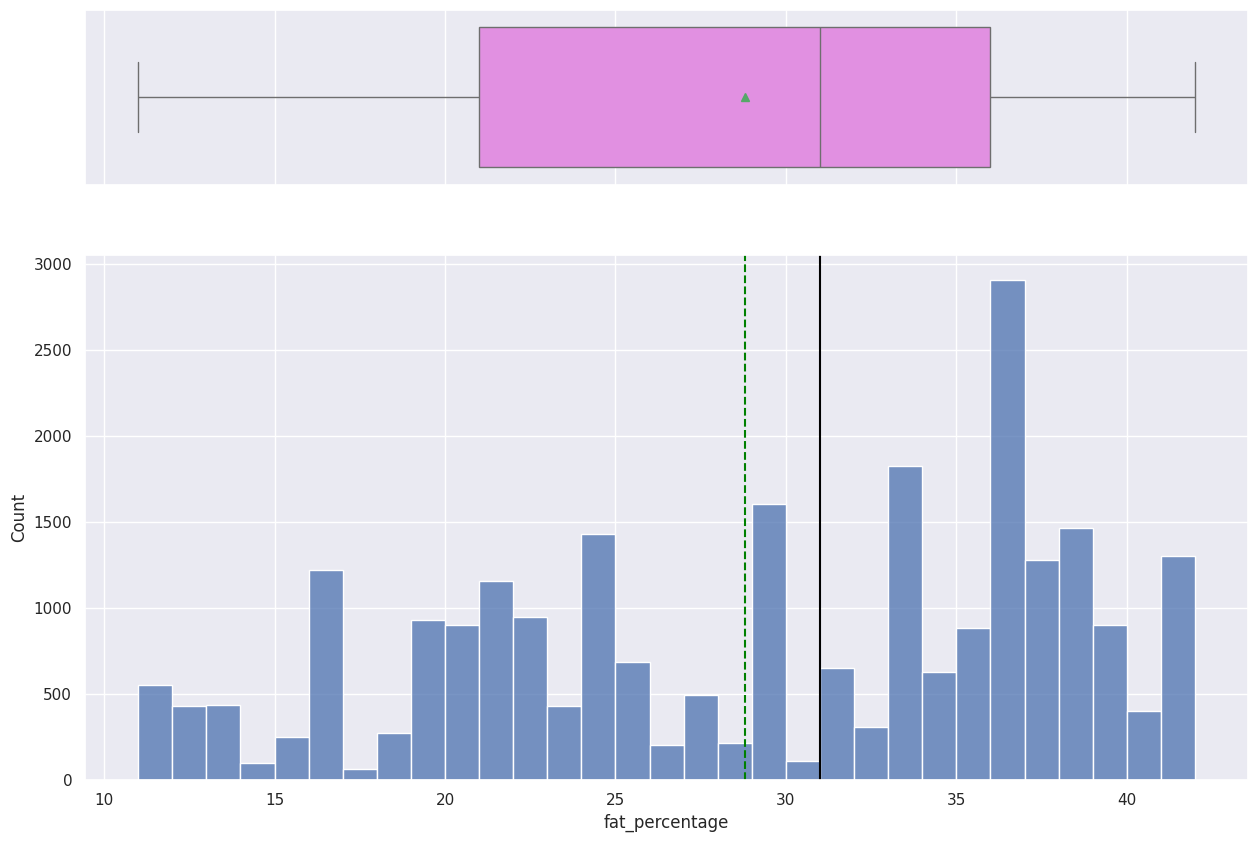

In [29]:
histogram_boxplot(df,'fat_percentage')

- The majority of the cohort has a high body fat percentage.
- The average body fat percentage in the cohort is 31.

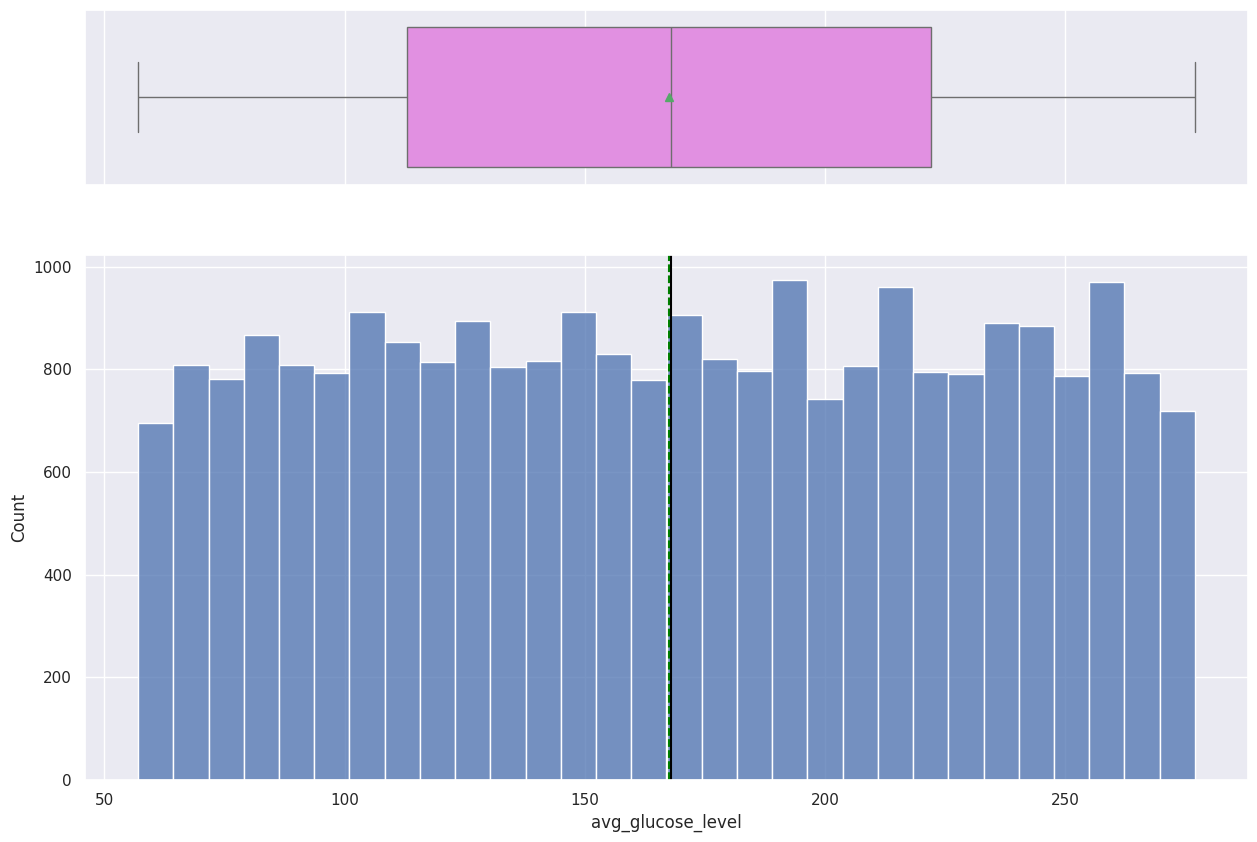

In [30]:
histogram_boxplot(df,'avg_glucose_level')

- The distribution's **mean and median glucose levels** in the population are **168**.

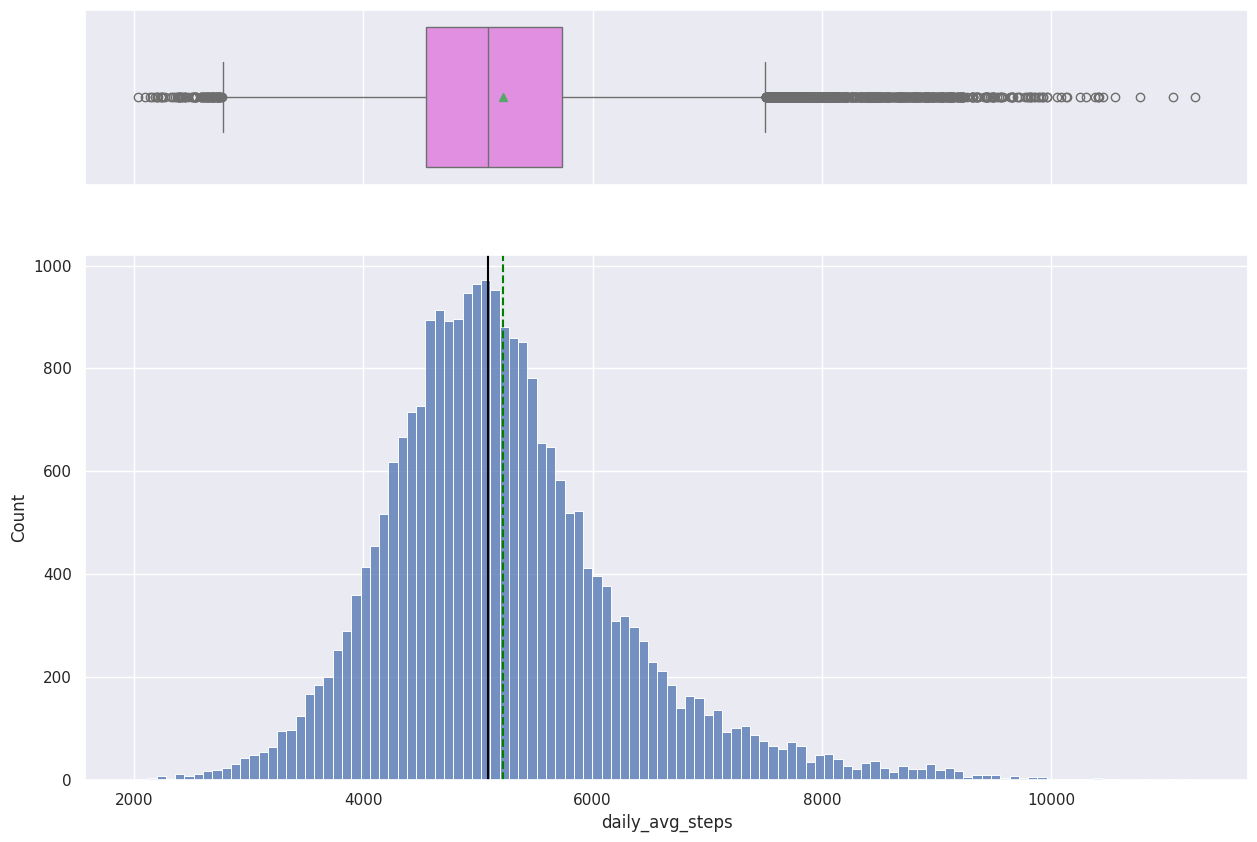

In [31]:
histogram_boxplot(df,'daily_avg_steps')

- The distribution appears to be normal, as the mean and median are nearly identical.
- Both positive and negative outliers are present.

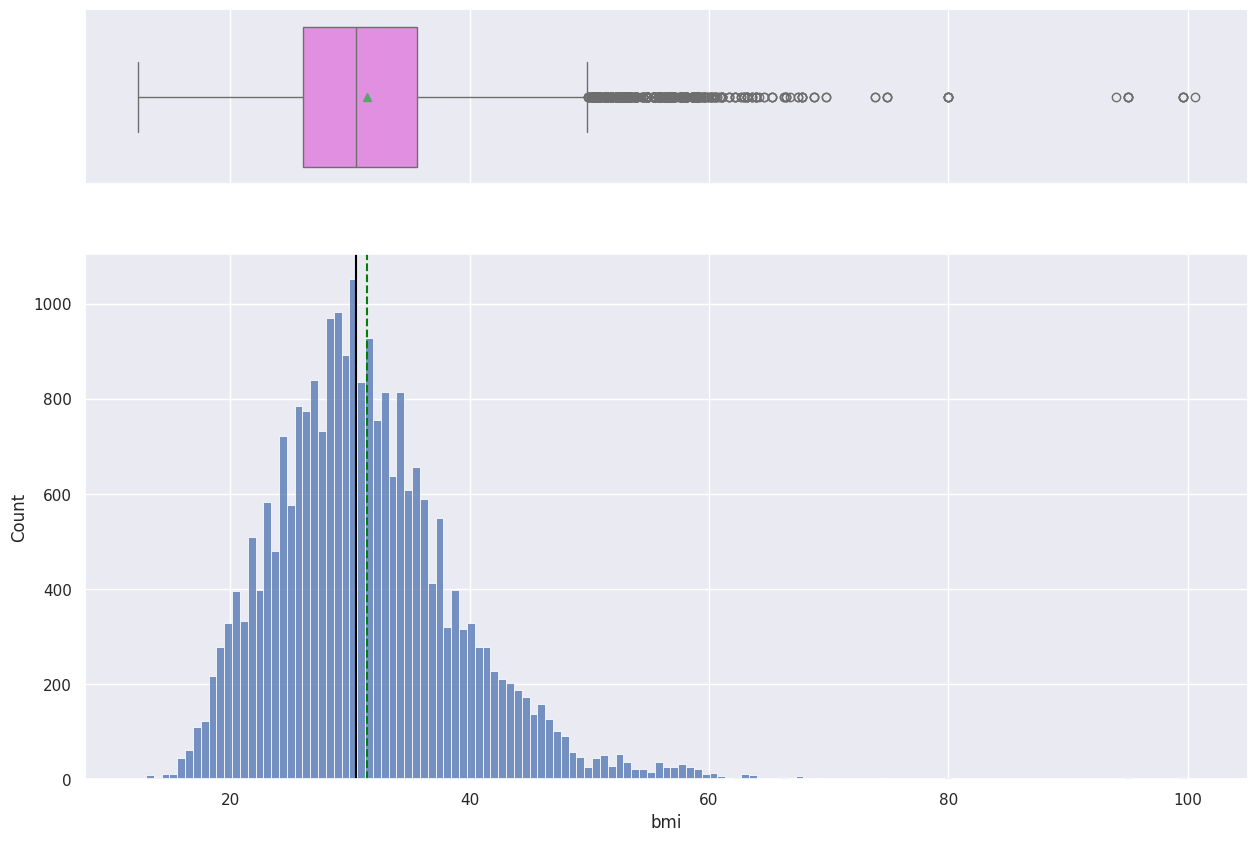

In [32]:
histogram_boxplot(df,'bmi')

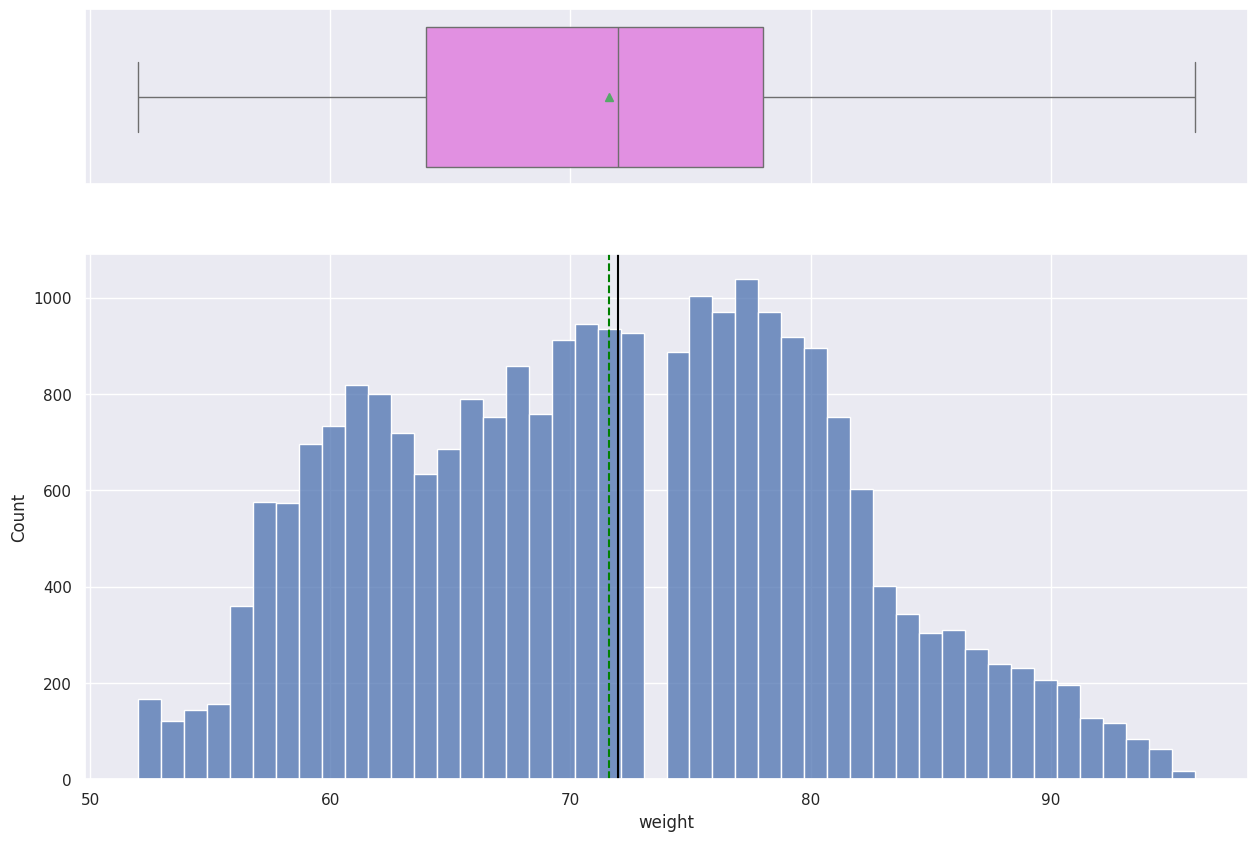

In [33]:
histogram_boxplot(df,'weight')

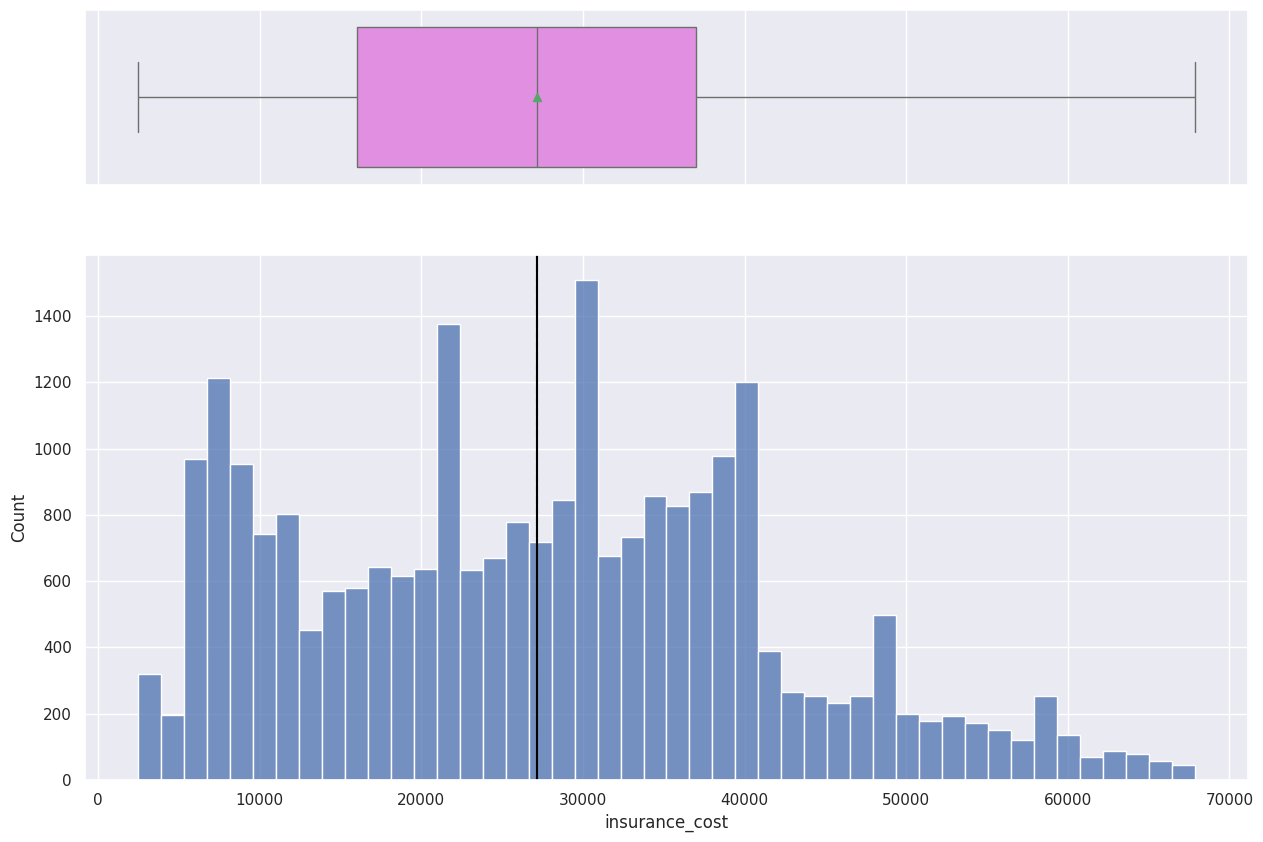

In [34]:
histogram_boxplot(df,'insurance_cost')

-	The mean and median for insurance cost are at the same position.
- A positive skewness is also observed.


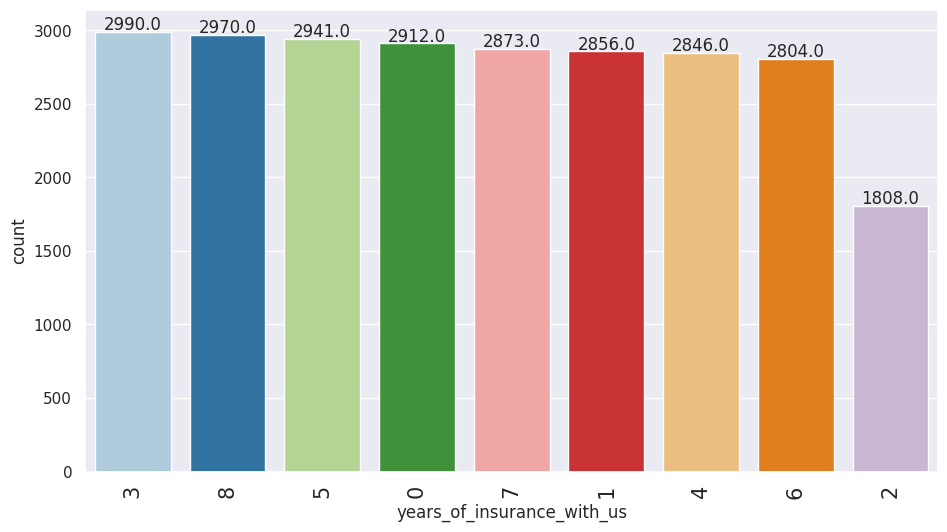

In [35]:
labeled_barplot(df,'years_of_insurance_with_us')

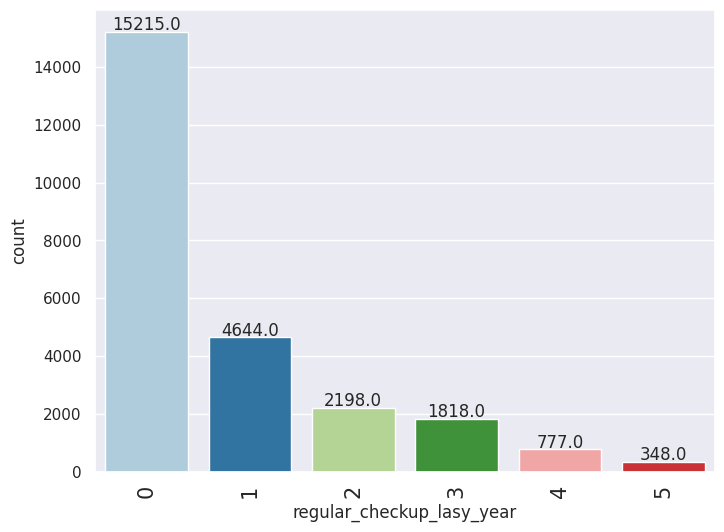

In [36]:
labeled_barplot(df,'regular_checkup_lasy_year')

- The majority of patients did not have a regular checkup last year.

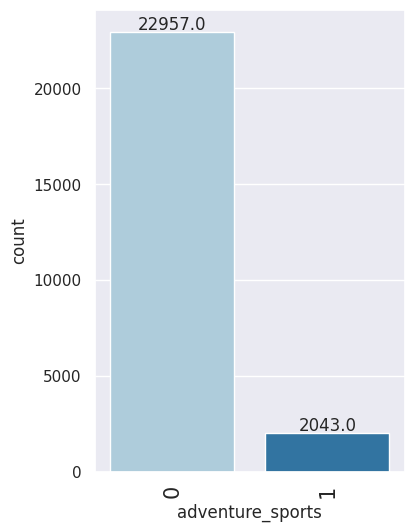

In [37]:
labeled_barplot(df,'adventure_sports')

- Only a **small number of people (2,043)** participate in adventure sports like **climbing and diving**.

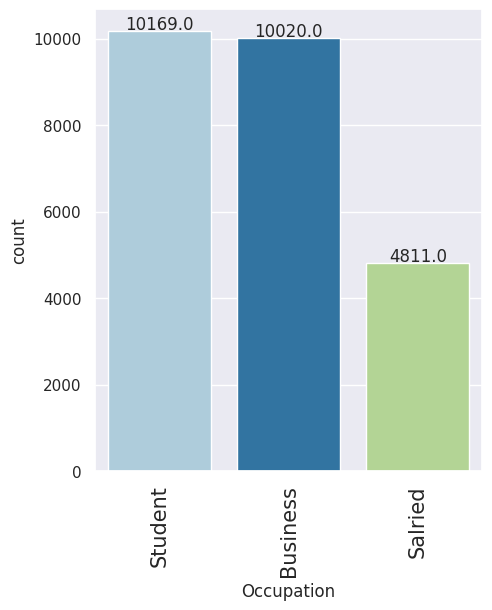

In [38]:
labeled_barplot(df,'Occupation')

- The majority of customers are engaged in **Student** or **Business** occupations, while **salaried employees** are relatively few.

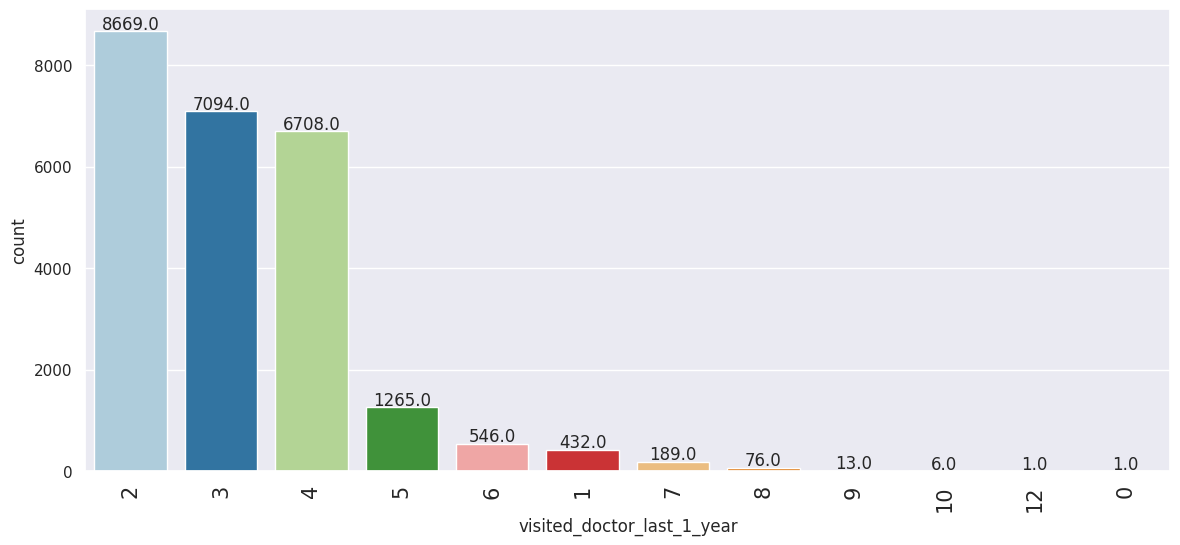

In [39]:
labeled_barplot(df,'visited_doctor_last_1_year')

- Most patients **visited the doctor** around **2 to 5 times** last year.

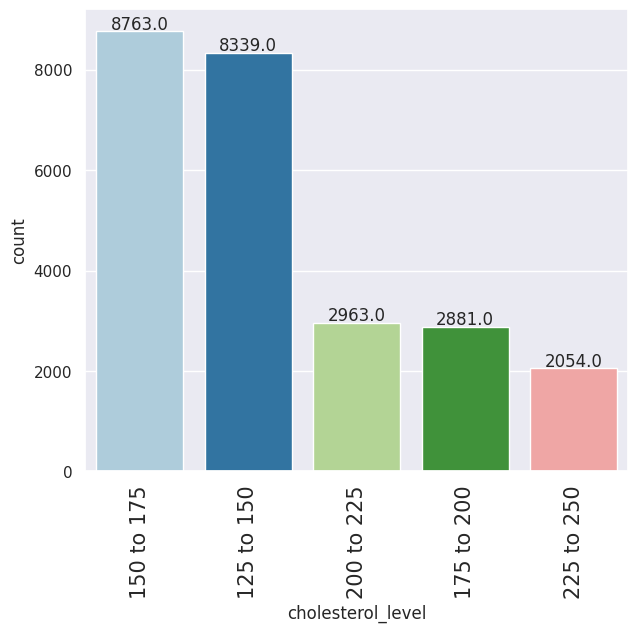

In [40]:
labeled_barplot(df,'cholesterol_level')

- The majority of customers have a **cholesterol level** between **125-150** and **150-175**.

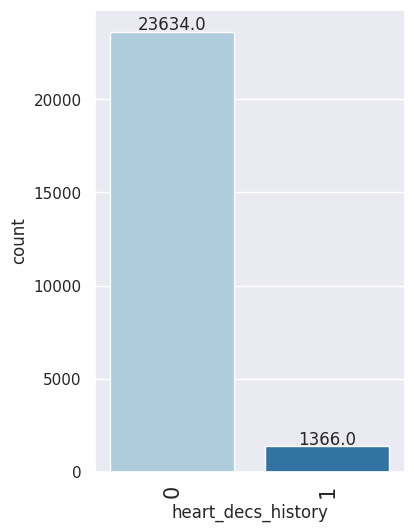

In [41]:
labeled_barplot(df,'heart_decs_history')

- Only a **small number of patients (1,366)** have a **history of heart disease**.

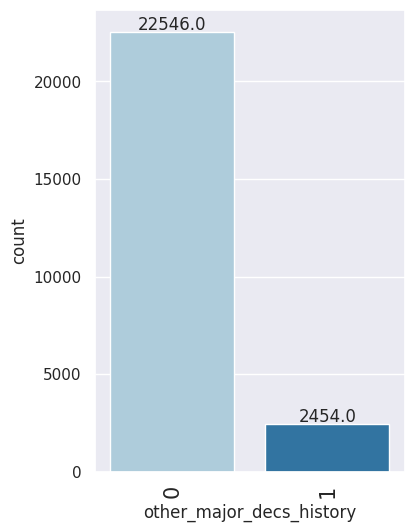

In [42]:
labeled_barplot(df,'other_major_decs_history')

- Only **2,454 people** have a history of **other major diseases**.

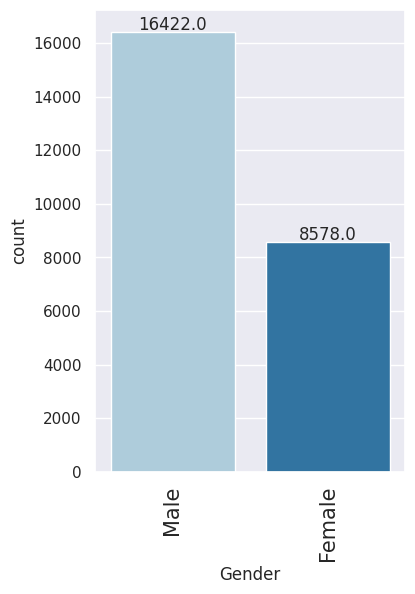

In [43]:
labeled_barplot(df,'Gender')

- The **gender distribution** in the data is approximately **2:1**.

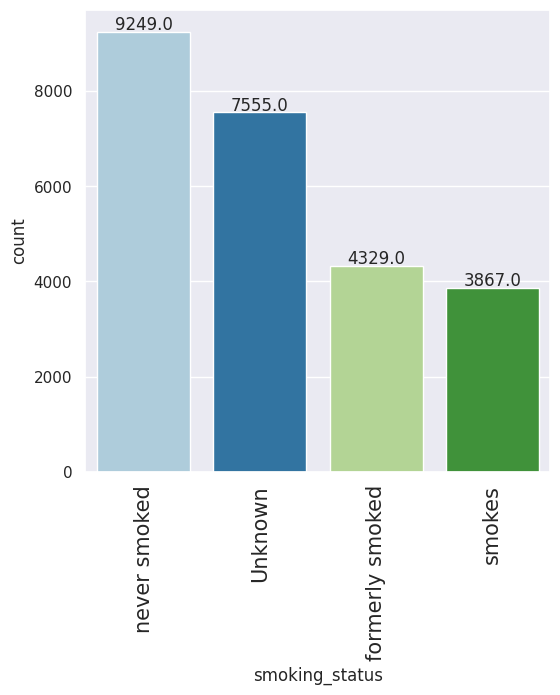

In [44]:
labeled_barplot(df,'smoking_status')

- The majority of customers **never smoked** or have an **unknown smoking status**.  
- The total number of customers who **formerly smoked** or **currently smoke** is approximately **8.2K**.

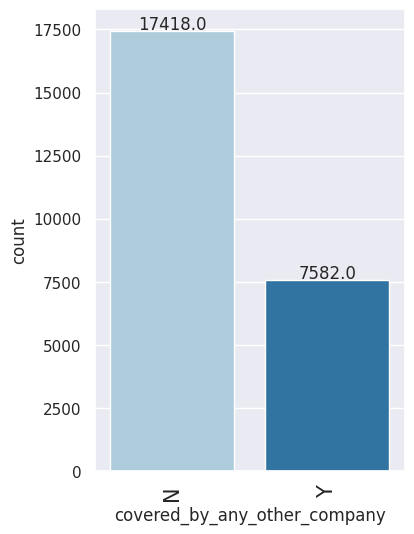

In [45]:
labeled_barplot(df,'covered_by_any_other_company')

- Around **7,582 customers** are covered by **another insurance**, accounting for **one-third** of the total dataset.

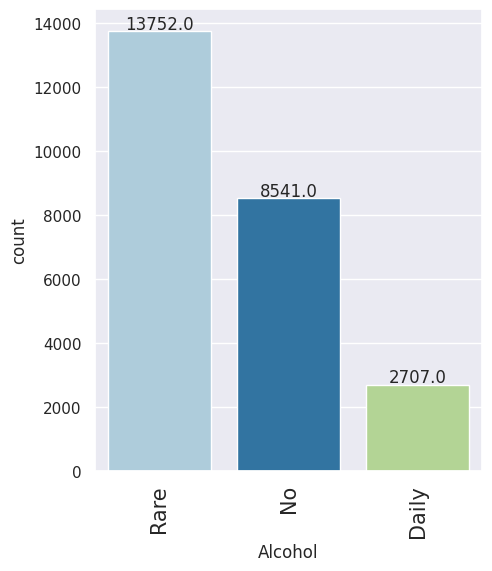

In [46]:
labeled_barplot(df,'Alcohol')

- Most of the custmers have rarely or did not have any previous alcoholic condition.

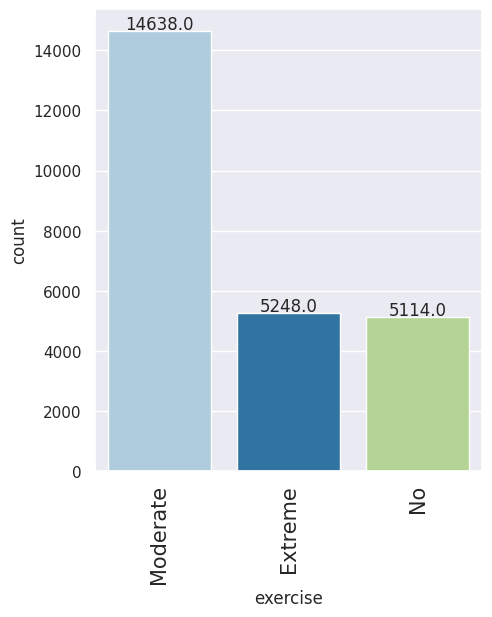

In [47]:
labeled_barplot(df,'exercise')

- The majority of customers engage in **moderate exercise**.

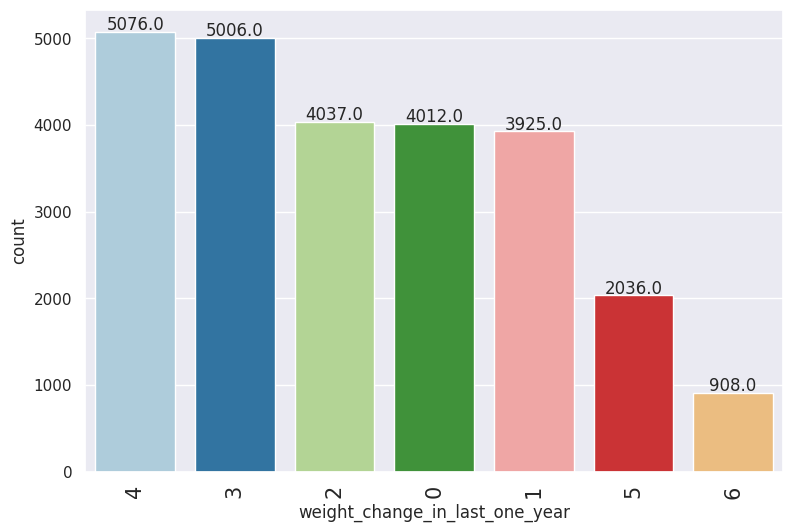

In [48]:
labeled_barplot(df,'weight_change_in_last_one_year')

- Most weight changes in the last year ranged between 1 to 4 kg.

### Bivariate Analysis

In [55]:
df1=Data.copy()
df1["Gender"] = df1["Gender"].apply(lambda x: 1 if x == "Male" else 0)
df1.drop(['applicant_id'],axis=1,inplace=True)
df1["covered_by_any_other_company"] = df1["covered_by_any_other_company"].apply(lambda x: 1 if x == "Y" else 0)

In [56]:
# Define labeling function
def label_Occupation(Occupation):
    if Occupation == "Salried":
        return 1
    elif Occupation =="Business":
        return 2
    else:
        return 0

# Apply the labeling function to the dataframe
df1['Occupation'] = df1['Occupation'].apply(label_Occupation)

In [57]:
# Define labeling function
def label_smoking_status(smoking_status):
    if smoking_status == "formerly smoked":
        return 1
    elif smoking_status =="smokes":
        return 2
    elif smoking_status =="Unknown":
        return 3
    else:
        return 0

# Apply the labeling function to the dataframe
df1['smoking_status'] = df1['smoking_status'].apply(label_smoking_status)

In [58]:
# Define labeling function
def label_Alcohol(Alcohol):
    if Alcohol == "Rare":
        return 1
    elif Alcohol =="Daily":
        return 2
    else:
        return 0

# Apply the labeling function to the dataframe
df1['Alcohol'] = df1['Alcohol'].apply(label_Alcohol)

In [59]:
# Define labeling function
def label_exercise(exercise):
    if exercise == "Moderate":
        return 1
    elif exercise =="Extreme":
        return 2
    else:
        return 0

# Apply the labeling function to the dataframe
df1['exercise'] = df1['exercise'].apply(label_exercise)

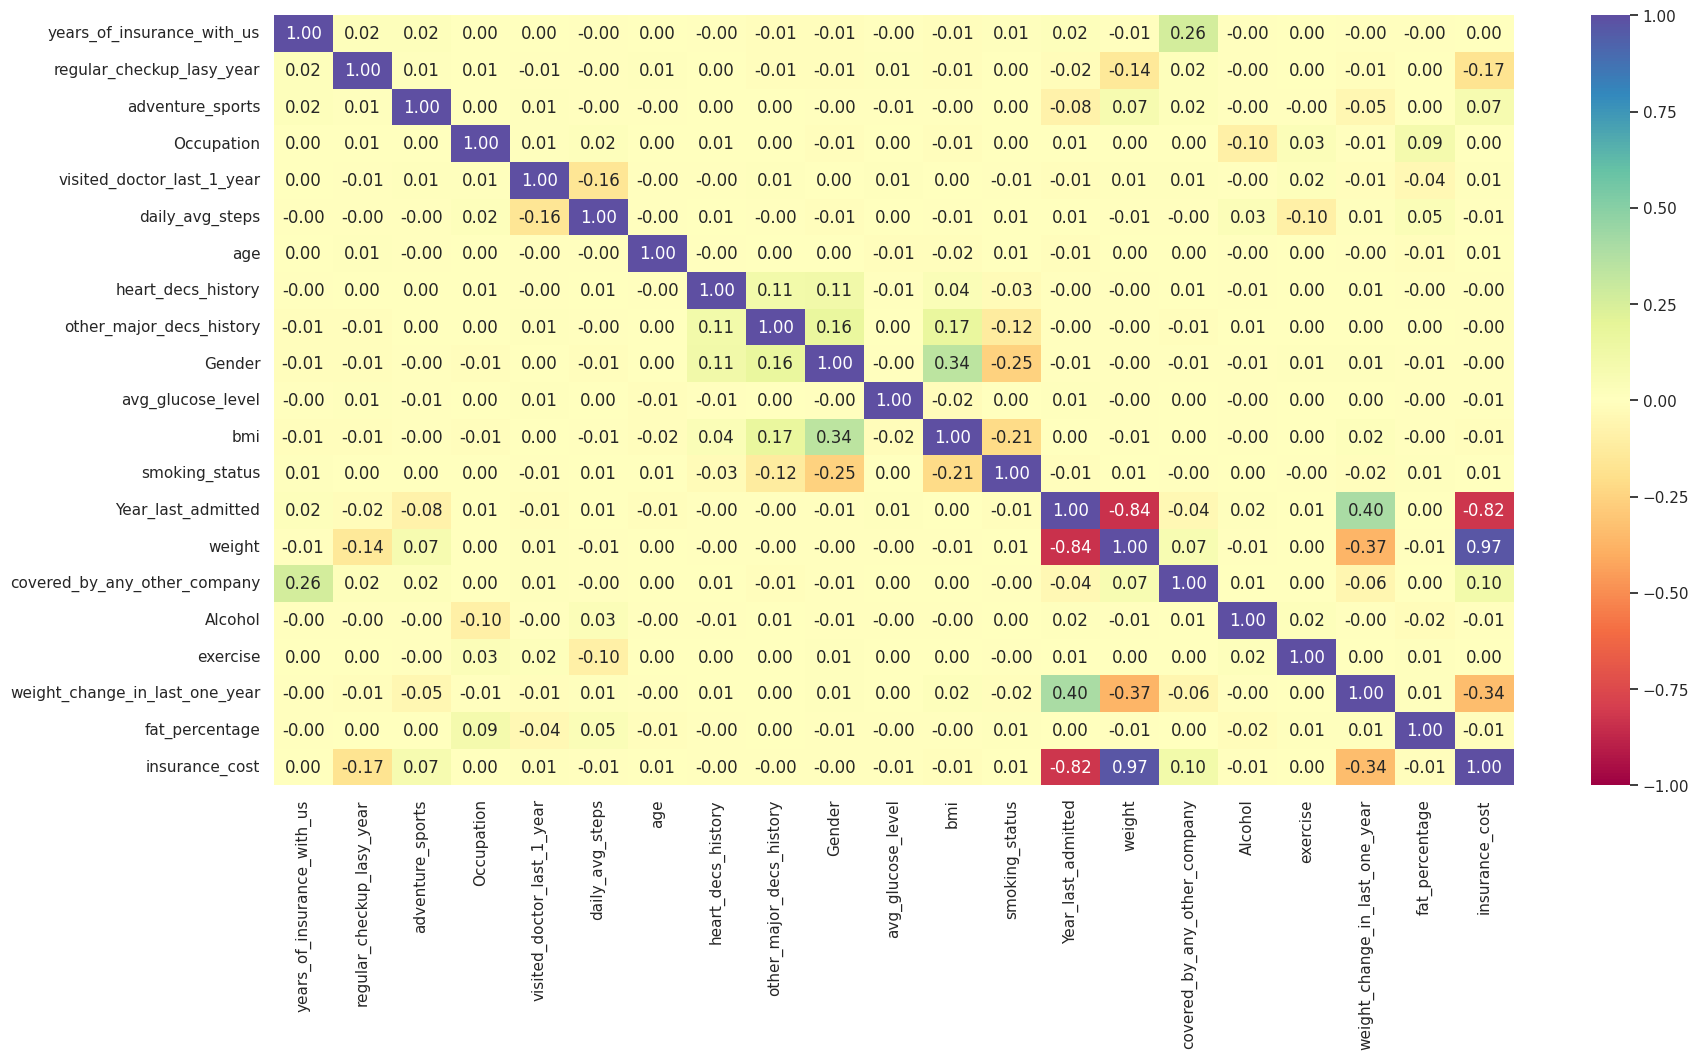

In [60]:
plt.figure(figsize=(20,10))
sns.heatmap(df1.corr(numeric_only=True),annot=True,vmin=-1,vmax=1,fmt='.2f',cmap="Spectral")
plt.show()

- A **strong positive correlation** is observed between **insurance cost** and **weight**.  
- A **strong negative correlation** exists between **year last admitted** and both **insurance cost** and **weight**.

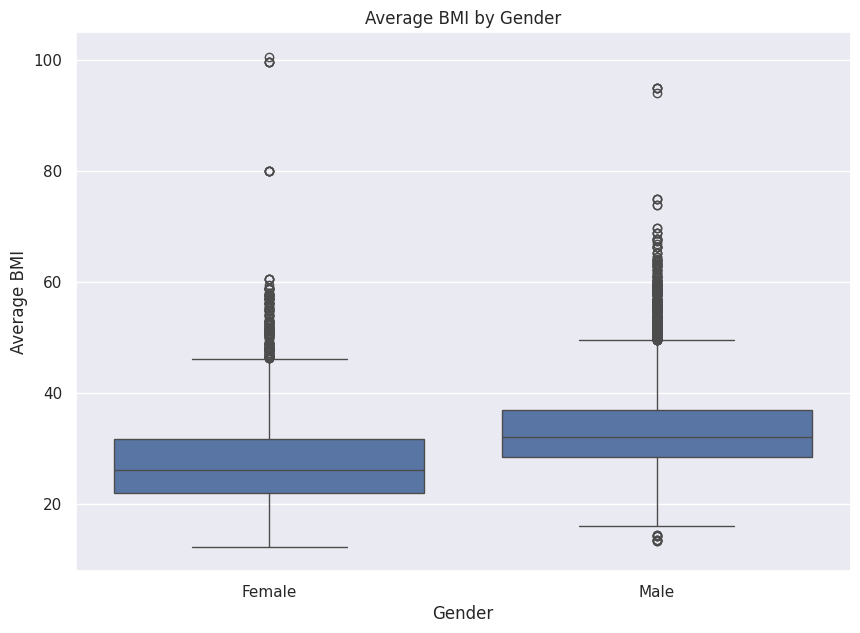

In [ ]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df,y='bmi',x='Gender')
plt.xlabel('Gender')
plt.ylabel('Average BMI')
plt.title('Average BMI by Gender');

- Female customers have a **lower average BMI** compared to male customers.

**We have created a new column with information of years passed after last admission.**

In [ ]:
# Number of years since last admitted
from datetime import datetime
current_year = datetime.now().year  # Get current year

# Create new column for the difference
df["Years_since_last_admission"] = current_year - df["Year_last_admitted"]

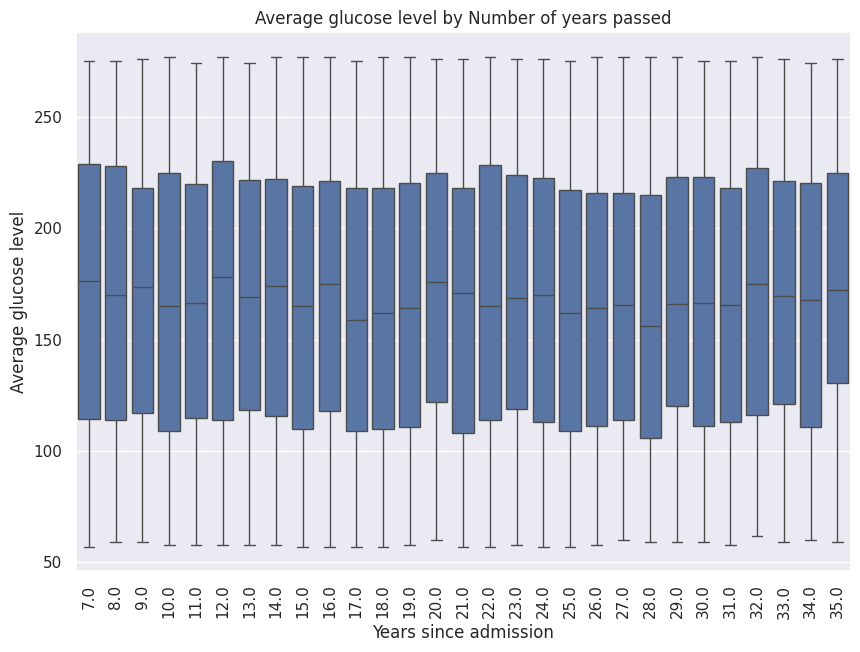

In [ ]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df,y='avg_glucose_level',x='Years_since_last_admission')
plt.xticks(rotation=90)
plt.xlabel('Years since admission')
plt.ylabel('Average glucose level')
plt.title('Average glucose level by Number of years passed');

- The **average glucose levels** have remained **relatively constant** over the years.

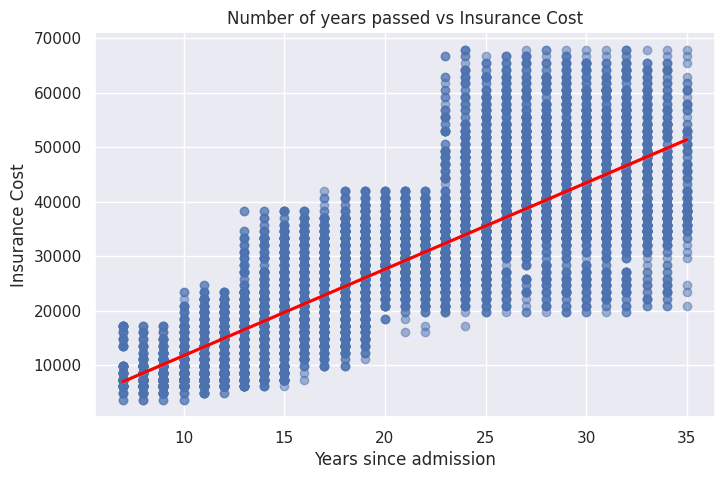

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(x=df['Years_since_last_admission'], y=df['insurance_cost'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Years since admission')
plt.ylabel('Insurance Cost')
plt.title('Number of years passed vs Insurance Cost')
plt.show()

- As the **number of years since last admission increases**, **insurance costs also increase**. This suggests that **insurance costs were higher in the past** and have **decreased over the years**.

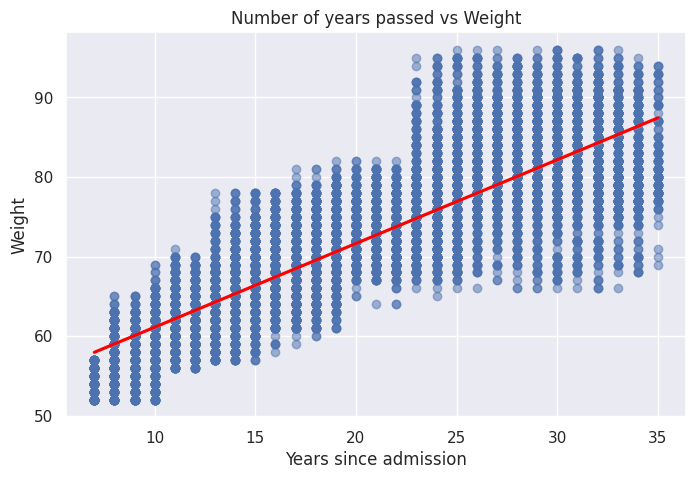

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(x=df['Years_since_last_admission'], y=df['weight'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Years since admission')
plt.ylabel('Weight')
plt.title('Number of years passed vs Weight')
plt.show()

- As the **number of years since last admission increases**, **customer weight also increases**, indicating that **obesity is more common among those who were admitted a long time ago**.

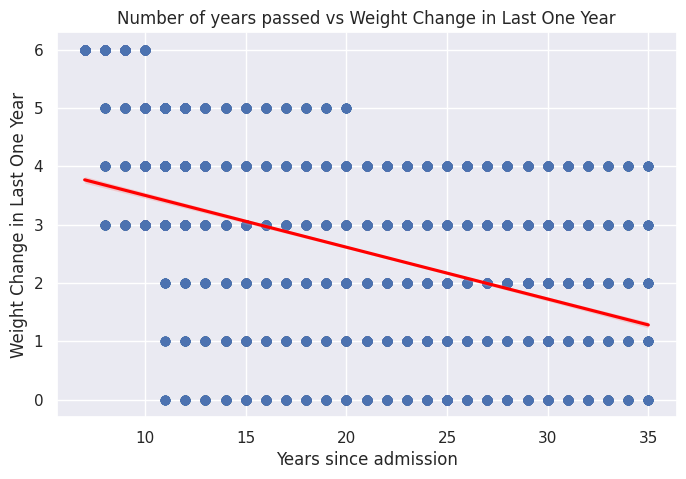

In [ ]:
plt.figure(figsize=(8,5))
sns.regplot(x=df['Years_since_last_admission'], y=df['weight_change_in_last_one_year'],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.xlabel('Years since admission')
plt.ylabel('Weight Change in Last One Year')
plt.title('Number of years passed vs Weight Change in Last One Year')
plt.show()

- The relationship between number of years passed and weight change in the last year shows a negative correlation. That means customers who were admitted a long time ago experience less weight fluctuation in the last year compared to those with more recent admissions.

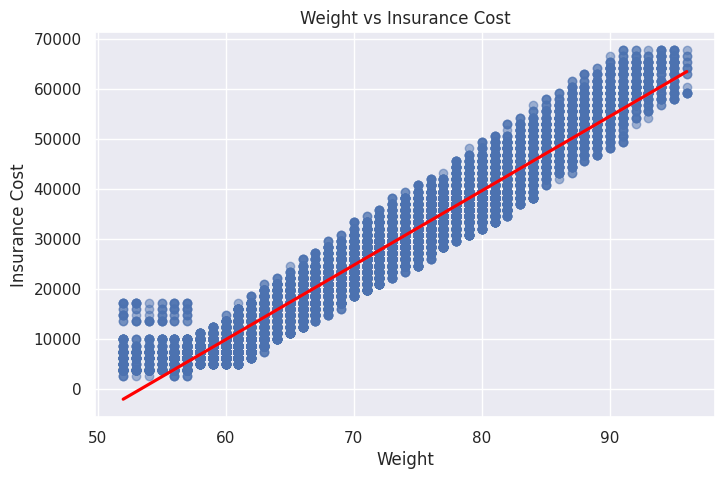

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(x=df['weight'], y=df['insurance_cost'],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.xlabel('Weight')
plt.ylabel('Insurance Cost')
plt.title('Weight vs Insurance Cost')
plt.show()

- As a customer's **weight increases**, their **insurance cost** also rises.

## Data Preprocessing

### Outlier Detection and Treatment

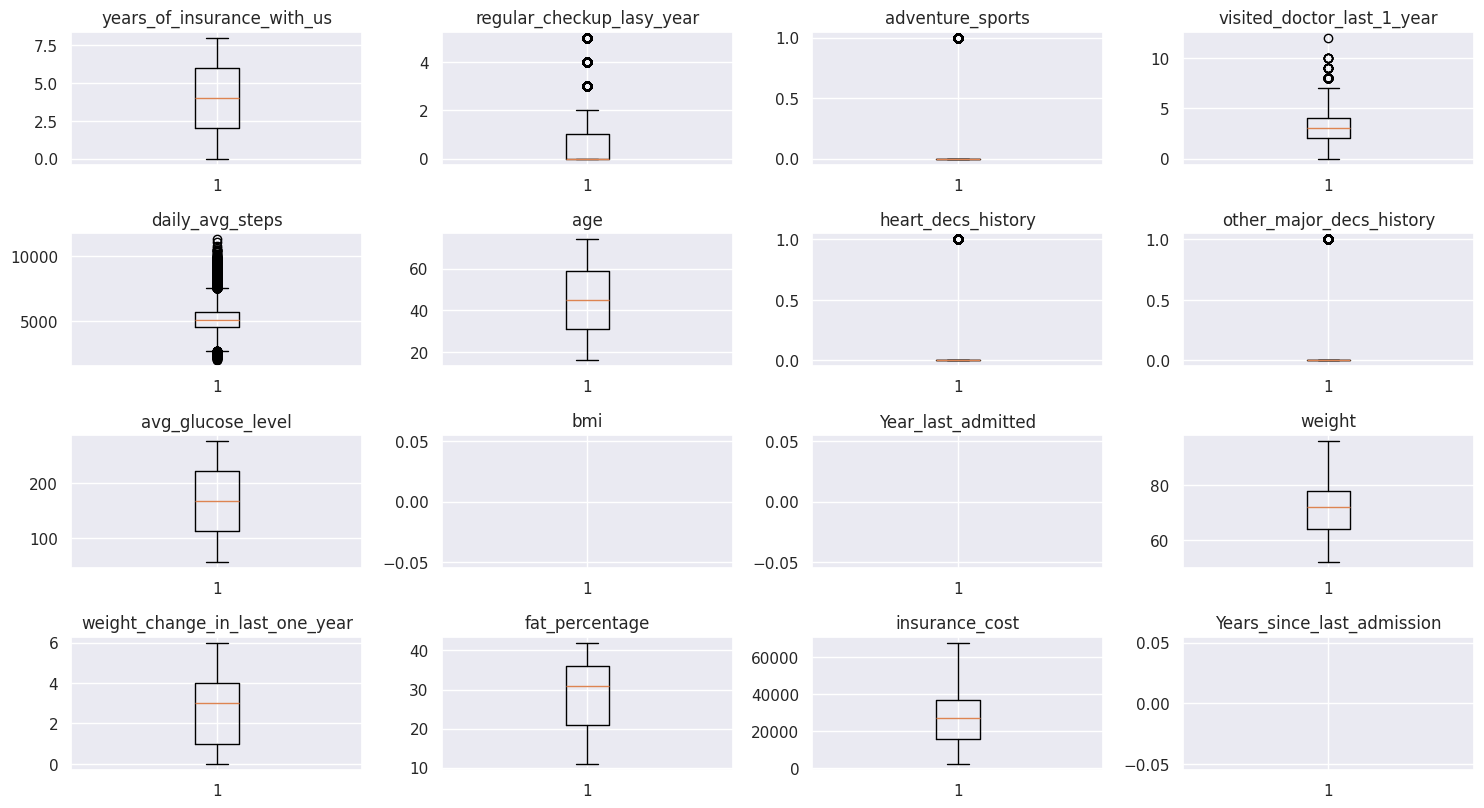

In [ ]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(6, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

- There are much a few outliers in the data.
- However, we will not treat them as they are proper values.

### Imputation of data

In [ ]:
# let's check again for missing values
df.isnull().sum()

,0
years_of_insurance_with_us,0
regular_checkup_lasy_year,0
adventure_sports,0
Occupation,0
visited_doctor_last_1_year,0
cholesterol_level,0
daily_avg_steps,0
age,0
heart_decs_history,0
other_major_decs_history,0


- If the year of admission is missing that means they never got admitted.

**We'll impute these missing Years_since_last_admission by filling -1.**

In [ ]:
df['Years_since_last_admission'].fillna(-1, inplace=True)

**Imputing the missing BMI values with the mean BMI of the corresponding gender.**

In [ ]:
df["bmi"] = df.groupby("Gender")["bmi"].transform(lambda x: x.fillna(x.mean()))

In [ ]:
# let's check again for missing values
df.isnull().sum()

,0
years_of_insurance_with_us,0
regular_checkup_lasy_year,0
adventure_sports,0
Occupation,0
visited_doctor_last_1_year,0
cholesterol_level,0
daily_avg_steps,0
age,0
heart_decs_history,0
other_major_decs_history,0


- **We will drop column Year_last_admitted later.**

- Now lets check the customer's profile who had never been admitted.

In [ ]:
# Filter for customers who have never been admitted
never_admitted = df[df['Years_since_last_admission'] == -1]

# Count occurrences of each occupation
never_admitted['Occupation'].value_counts()

,count
Occupation,
Student,4794
Business,4714
Salried,2373


In [ ]:
never_admitted['Gender'].value_counts()

,count
Gender,
Male,7879
Female,4002


In [ ]:
never_admitted['years_of_insurance_with_us'].value_counts()

,count
years_of_insurance_with_us,
0,2912
1,2856
2,1808
8,754
5,741
3,725
7,704
6,704
4,677


- Most of the not admitted customers were connected wuth us within 0 - 2 years.

In [ ]:
never_admitted['covered_by_any_other_company'].value_counts()

,count
covered_by_any_other_company,
N,9532
Y,2349


- Most of them not covered by any other company.

### Variables Transformation

In [ ]:
# Log transformation for skewed numerical features
for feature in ['insurance_cost', 'avg_glucose_level', 'bmi', 'daily_avg_steps']:
    df[feature] = np.log1p(df[feature])

### Feature Engineering

To prepare the dataset for regression modeling, categorical variables were transformed into numerical representations through mapping techniques. The **Occupation** variable was converted into ordinal values, with 'Salried' mapped to 1, 'Business' to 2, and 'Student' to 0. Similarly, **cholesterol levels** were assigned numerical ranks from 1 to 5 based on their range, ensuring a structured representation of increasing levels. **Gender** was converted into a binary format, with 'Male' as 1 and 'Female' as 0, allowing the model to interpret this variable effectively.  

Lifestyle factors such as **smoking status**, **alcohol consumption**, and **exercise habits** were also numerically encoded. The smoking variable was assigned increasing values from 0 to 3, reflecting the progression from 'Unknown' to active smoking. Alcohol consumption was categorized into three levels, where 'No' drinking was 0, 'Rare' was 1, and 'Daily' was 2. Similarly, exercise levels were encoded as 0 for 'No', 1 for 'Moderate', and 2 for 'Extreme'. Additionally, the **covered_by_any_other_company** variable was converted into binary form, with 'N' mapped to 0 and 'Y' to 1. These transformations ensure that all categorical data are in a numerical format, making them compatible with machine learning models and facilitating meaningful pattern recognition.

In [ ]:
Occupation_mapping= {'Salried':1,'Business':2,'Student':0}
df['Occupation']= df['Occupation'].map(Occupation_mapping)

cholesterol_mapping = {
    '125 to 150': 1,
    '150 to 175': 2,
    '175 to 200': 3,
    '200 to 225': 4,
    '225 to 250': 5
}
df['cholesterol_level'] = df['cholesterol_level'].map(cholesterol_mapping)

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

smoking_mapping = {
    'Unknown': 0,
    'never smoked': 1,
    'formerly smoked': 2,
    'smokes': 3
}
df['smoking_status'] = df['smoking_status'].map(smoking_mapping)

alcohol_mapping = {'No': 0, 'Rare': 1, 'Daily': 2}
df['Alcohol'] = df['Alcohol'].map(alcohol_mapping)

exercise_mapping = {'No': 0, 'Moderate': 1, 'Extreme': 2}
df['exercise'] = df['exercise'].map(exercise_mapping)


df['covered_by_any_other_company']=df['covered_by_any_other_company'].map({'N':0,'Y':1})

-	The following columns were dropped: `Location`, and `Year_last_admitted` as they don’t contribute any relation with the dependent variable.

In [ ]:
df.drop(columns=['Year_last_admitted','Location'], inplace=True)

## Model Building - Linear Regression

In [ ]:
# defining the dependent and independent variables
X = df.drop(["insurance_cost"], axis=1)
y = df["insurance_cost"]

In [ ]:
X.head()

,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,...,avg_glucose_level,bmi,smoking_status,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,Years_since_last_admission
0,3,1,1,1,2,1,8.490233,28,1,0,...,4.584967,3.471966,0,67,0,1,1,1,25,-1.0
1,0,0,0,0,4,2,8.765927,50,0,0,...,5.361292,3.561046,2,58,0,1,1,3,27,-1.0
2,1,0,0,2,4,4,8.414052,68,0,0,...,5.117994,3.723281,2,73,0,2,2,0,32,-1.0
3,7,4,0,2,2,3,8.734721,51,0,0,...,4.700480,3.173878,0,71,1,1,0,3,37,-1.0
4,3,1,0,0,2,2,8.504918,44,0,1,...,4.779123,3.314186,1,74,0,0,2,0,34,21.0


In [ ]:
columns= X.columns
list(columns)

['years_of_insurance_with_us',
 'regular_checkup_lasy_year',
 'adventure_sports',
 'Occupation',
 'visited_doctor_last_1_year',
 'cholesterol_level',
 'daily_avg_steps',
 'age',
 'heart_decs_history',
 'other_major_decs_history',
 'Gender',
 'avg_glucose_level',
 'bmi',
 'smoking_status',
 'weight',
 'covered_by_any_other_company',
 'Alcohol',
 'exercise',
 'weight_change_in_last_one_year',
 'fat_percentage',
 'Years_since_last_admission']

In [ ]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 17500
Number of rows in test data = 7500


In [ ]:
# statsmodels does not add a constant by default. We need to add it explicitly.
x_train = sm.add_constant(x_train)
# Add constant to test data
x_test = sm.add_constant(x_test)

# fitting a linear model
olsmodel1 = sm.OLS(y_train, x_train).fit()
print(olsmodel1.summary())

                            OLS Regression Results                            
Dep. Variable:         insurance_cost   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     6124.
Date:                Thu, 06 Mar 2025   Prob (F-statistic):               0.00
Time:                        04:59:38   Log-Likelihood:                 1040.6
No. Observations:               17500   AIC:                            -2037.
Df Residuals:                   17478   BIC:                            -1866.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

- Let us check the VIF scores.

In [ ]:
pd.set_option("display.max_rows", None)  # Show all rows
pd.set_option("display.max_columns", None)  # Show all columns if needed
pd.set_option("display.float_format", "{:.6f}".format)  # Format float output

# Compute and print VIF
vif_series = pd.Series(
    [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])],
    index=x_train.columns,
    dtype=float,
)
print("Series before feature selection: \n\n{}\n".format(vif_series))

Series before feature selection: 

const                            2578.850824
years_of_insurance_with_us          1.506506
regular_checkup_lasy_year           1.108365
adventure_sports                    1.008766
Occupation                          1.372266
visited_doctor_last_1_year          1.035088
cholesterol_level                   1.364573
daily_avg_steps                     1.045616
age                                 1.000710
heart_decs_history                  1.025073
other_major_decs_history            1.050622
Gender                              1.256624
avg_glucose_level                   1.001210
bmi                                 1.227343
smoking_status                      1.125678
weight                              1.458831
covered_by_any_other_company        1.089420
Alcohol                             1.013672
exercise                            1.013997
weight_change_in_last_one_year      1.171785
fat_percentage                      1.016674
Years_since_last_adm

- The Variance Inflation Factor (VIF) scores are below 3, indicating that multicollinearity is not a concern in the dataset. This suggests that the independent variables are not highly correlated with each other, ensuring the stability and reliability of the regression model.

- Need to remove variables having higher p value.

In [ ]:
# initial list of columns
cols = x_train.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = x_train[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'regular_checkup_lasy_year', 'adventure_sports', 'Occupation', 'weight', 'covered_by_any_other_company', 'weight_change_in_last_one_year', 'Years_since_last_admission']


In [ ]:
x_train2 = x_train[selected_features]..

In [ ]:
# fitting a linear model
olsmodel2 = sm.OLS(y_train, x_train2).fit()
print(olsmodel2.summary())

                            OLS Regression Results                            
Dep. Variable:         insurance_cost   R-squared:                       0.880
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                 1.838e+04
Date:                Thu, 06 Mar 2025   Prob (F-statistic):               0.00
Time:                        04:59:38   Log-Likelihood:                 1037.0
No. Observations:               17500   AIC:                            -2058.
Df Residuals:                   17492   BIC:                            -1996.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [ ]:
x_test1 = x_test[selected_features]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train model
lr = LinearRegression()
lr.fit(x_train2, y_train)

# Predictions
y_train_pred = lr.predict(x_train2)  # Predictions for training set
y_test_pred = lr.predict(x_test1)  # Predictions for test set

# Number of samples and features
n_train, p = x_train2.shape  # Training data: n = samples, p = features
n_test = x_test1.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# Store Training Set Results
Linear_regression_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
Linear_regression_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", Linear_regression_Train)
print("\n🔹 Test Set Metrics:", Linear_regression_Test)


🔹 Training Set Metrics: {'R²': 0.8803, 'Adj. R²': 0.8803, 'RMSE': 0.23, 'MAE': 0.18, 'MAPE (%)': 1.82}

🔹 Test Set Metrics: {'R²': 0.8832, 'Adj. R²': 0.883, 'RMSE': 0.22, 'MAE': 0.17, 'MAPE (%)': 1.78}


### Observations on Regression Modeling:

- **Good Model Fit:**  
  - The **R² values** are 0.8803 (training) and 0.8832 (test), indicating that the model explains around **88%** of the variance in the target variable.  
  - **Adjusted R²** values remain close to R², confirming that the model is not overfitting and effectively utilizes the predictors.  

- **Low Prediction Errors:**  
  - **RMSE:** 0.23 (train) and 0.22 (test), indicating minimal error in predictions.  
  - **MAE:** 0.18 (train) and 0.17 (test), showing that the average absolute prediction error is very small.  
  - **MAPE:** 1.82% (train) and 1.78% (test), suggesting that the model’s percentage error is very low.  

- **Strong Generalization:**  
  - The minimal difference between training and test set performance confirms that the model generalizes well and does not suffer from overfitting.  
  - The metrics indicate a reliable and well-optimized linear regression model for predicting the target variable.  

Now we'll check the rest of the assumptions on olsmod2.

1.   Linearity of variables
2.   Independence of error terms
3.   Normality of error terms
4.   No Heteroscedasticity
5.   No strong Multicollinearity

### Assumptions of Linear Regression

These assumptions are essential conditions that should be met before we draw inferences regarding the model estimates or use the model to make a prediction.

For Linear Regression, we need to check if the following assumptions hold:-

1. Linearity
2. Independence
3. Homoscedasticity
4. Normality of error terms
5. No strong Multicollinearity

In [ ]:
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train.values.flatten()  # actual values
df_pred["Fitted Values"] = olsmodel2.fittedvalues.values  # predicted values
df_pred["Residuals"] = olsmodel2.resid.values  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
0,10.253546,10.186066,0.067480
1,10.062498,9.727960,0.334538
2,10.755624,10.706886,0.048738
3,10.614548,10.756445,-0.141897
4,10.376144,10.557775,-0.181631


### TEST FOR LINEARITY AND INDEPENDENCE
**Why the test?**

- Linearity describes a straight-line relationship between two variables, predictor variables must have a linear relation with the dependent variable.

**How to check linearity?**

- Make a plot of fitted values vs residuals. If they don't follow any pattern (the curve is a straight line), then we say the model is linear otherwise model is showing signs of non-linearity.

**How to fix if this assumption is not followed?**

- We can try different transformations.

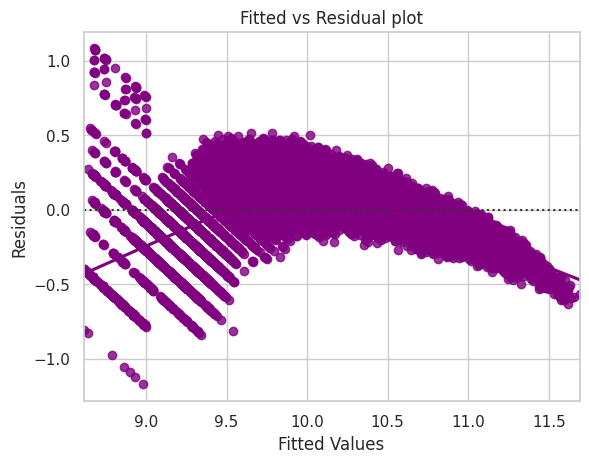

In [ ]:
# let us plot the fitted values vs residuals
sns.set_style("whitegrid")
sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

- The scatter plot shows the distribution of residuals (errors) vs fitted values (predicted values).

- If there exist any pattern in this plot, we consider it as signs of non-linearity in the data and a pattern means that the model doesn't capture non-linear effects.

- **We see no pattern in the plot above. Hence, the assumptions of linearity and independence are satisfied.**

### TEST FOR NORMALITY
What is the test?

- Error terms/residuals should be normally distributed.

- If the error terms are not normally distributed, confidence intervals may become too wide or narrow. Once confidence interval becomes unstable, it leads to difficulty in estimating coefficients based on minimization of least squares.

What does non-normality indicate?

- It suggests that there are a few unusual data points which must be studied closely to make a better model.

How to check the Normality?

- It can be checked via QQ Plot - residuals following normal distribution will make a straight line plot, otherwise not.

- Another test to check for normality is the Shapiro-Wilk test.

How to Make residuals normal?

- We can apply transformations like log, exponential, arcsinh, etc as per our data.


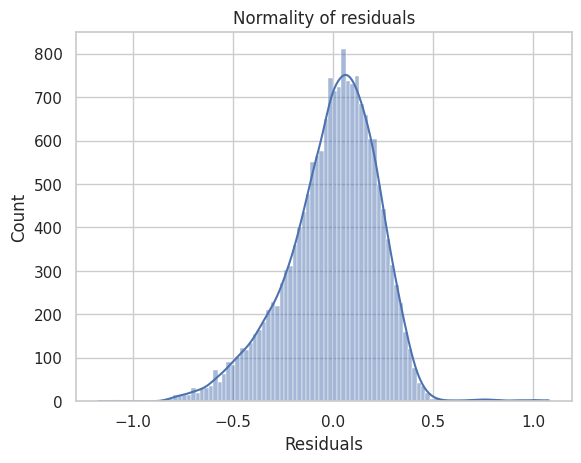

In [ ]:
sns.histplot(df_pred["Residuals"], kde=True)
plt.title("Normality of residuals")
plt.show()

- The residual terms are normally distributed

**The Q-Q plot of residuals can be used to visually check the normality assumption. The normal probability plot of residuals should approximately follow a straight line.**

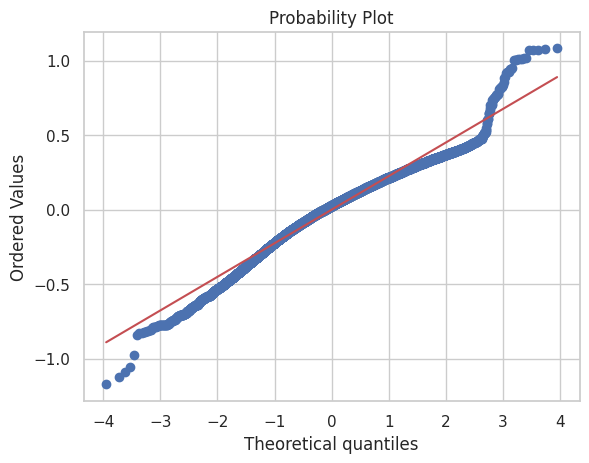

In [ ]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

- Most of the points are lying out of the straight line in QQ plot

The **Shapiro-Wilk** test can also be used for checking the normality. The null and alternate hypotheses of the test are as follows:

- Null hypothesis - Data is normally distributed.
- Alternate hypothesis - Data is not normally distributed.

In [ ]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=0.9756950484397175, pvalue=9.40347720736352e-47)

Since p-value < 0.05, the residuals are not normal as per shapiro test.

### TEST FOR HOMOSCEDASTICITY
- Homoscedacity - If the variance of the residuals are symmetrically distributed across the regression line , then the data is said to homoscedastic.

- Heteroscedacity - If the variance is unequal for the residuals across the regression line, then the data is said to be heteroscedastic. In this case the residuals can form an arrow shape or any other non symmetrical shape.

Why the test?

- The presence of non-constant variance in the error terms results in heteroscedasticity. Generally, non-constant variance arises in presence of outliers.
How to check if model has Heteroscedasticity?

- Can use the goldfeldquandt test. If we get p-value > 0.05 we can say that the residuals are homoscedastic, otherwise they are heteroscedastic.
How to deal with Heteroscedasticity?

- Can be fixed via adding other important features or making transformations.
The null and alternate hypotheses of the goldfeldquandt test are as follows:

Null hypothesis : Residuals are homoscedastic
Alternate hypothesis : Residuals have hetroscedasticity


In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

In [ ]:
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train2)
lzip(name, test)

[('F statistic', 1.0243881179463996), ('p-value', 0.12999779120605062)]

- Since p-value > 0.05 we can say that the residuals are homoscedastic.

In [ ]:
# predictions on the test set
pred = olsmodel2.predict(x_test1)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
6824,9.683028,9.586803
6673,10.336924,10.259412
5822,10.162577,10.186868
7829,10.413883,10.015741
4075,10.062498,9.860857
24688,9.602990,9.434193
13129,10.450250,10.424869
5146,9.602990,9.715760
9958,10.989234,11.067357
8130,10.162577,10.177551


- We can observe here that our model has returned pretty good prediction results, and the actual and predicted values are comparable

## **Decision Tree Regressor**

In [ ]:
dtree = DecisionTreeRegressor(criterion='squared_error', random_state=1)

In [ ]:
# Train model
dtree.fit(x_train, y_train)

# Predictions
y_train_pred = dtree.predict(x_train)  # Predictions for training set
y_test_pred = dtree.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
Dtree_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
Dtree_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", Dtree_Train)
print("\n🔹 Test Set Metrics:", Dtree_Test)


🔹 Training Set Metrics: {'R²': 1.0, 'Adj. R²': 1.0, 'RMSE': 0.0, 'MAE': 0.0, 'MAPE (%)': 0.0}

🔹 Test Set Metrics: {'R²': 0.8923, 'Adj. R²': 0.892, 'RMSE': 0.21, 'MAE': 0.15, 'MAPE (%)': 1.57}


#### Observations on the Decision Tree Regression Model:

- The **training set metrics** indicate perfect model performance, with **R² = 1.0**, **RMSE = 0.0**, **MAE = 0.0**, and **MAPE = 0.0%**. This suggests that the model has completely memorized the training data, leading to **overfitting**.  
- On the **test set**, the model achieves **R² = 0.8923**, which is relatively high, indicating good predictive power. However, the drop from perfect training performance to a lower test performance suggests that the model may not generalize well to unseen data.  
- The **RMSE (0.21) and MAE (0.15)** on the test set indicate some prediction errors, though they remain within a reasonable range. The **MAPE of 1.57%** shows that the model's percentage error is low.  
- Overall, while the Decision Tree performs well on the test set, the extreme overfitting on the training data suggests that **pruning or tuning hyperparameters** (such as max depth, min samples split, or min samples leaf) may be necessary to improve generalization and prevent overfitting.

#### Tuning of Decision Tree

In [ ]:
# Choose the type of classifier.
dtree_estimator = DecisionTreeRegressor(criterion='squared_error',random_state=1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2,30),
              'min_samples_leaf': [1, 2, 5, 7, 10],
              'max_leaf_nodes' : [2, 3, 5, 10,15],
              'min_impurity_decrease': [0.0001,0.001,0.01,0.1]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
dtree_estimator = grid_obj.best_estimator_

In [ ]:
# Fit the best algorithm to the data.
dtree_estimator.fit(x_train, y_train)

# Predictions
y_train_pred = dtree_estimator.predict(x_train)  # Predictions for training set
y_test_pred = dtree_estimator.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
Dtree_Estimator_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
Dtree_Estimator_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", Dtree_Estimator_Train)
print("\n🔹 Test Set Metrics:", Dtree_Estimator_Test)


🔹 Training Set Metrics: {'R²': 0.7093, 'Adj. R²': 0.7089, 'RMSE': 0.36, 'MAE': 0.29, 'MAPE (%)': 2.91}

🔹 Test Set Metrics: {'R²': 0.6966, 'Adj. R²': 0.6957, 'RMSE': 0.36, 'MAE': 0.29, 'MAPE (%)': 2.93}


#### Observations on the Tuned Decision Tree Model:

- The **training set performance** shows an **R² of 0.7093**, indicating that the model explains approximately **71% of the variance** in the training data. The **RMSE (0.36) and MAE (0.29)** suggest moderate errors, and the **MAPE of 2.91%** indicates that, on average, predictions deviate by about **2.91%** from actual values.  
- The **test set performance** is similar, with an **R² of 0.6966**, showing that the model maintains its predictive ability on unseen data. The **RMSE (0.36) and MAE (0.29)** remain consistent, suggesting that the model is **not overfitting** and generalizes well.  
- Compared to the **untuned Decision Tree**, which was highly overfitted, the tuned model has **better generalization**, though at the cost of lower training accuracy. This balance suggests that **pruning and hyperparameter tuning** have effectively reduced overfitting while maintaining reasonable predictive power.  
- Overall, while the model performs well, further improvements could be achieved by experimenting with **feature selection, ensemble methods (such as Random Forest or Gradient Boosting), or fine-tuning additional hyperparameters** to enhance accuracy.

In [ ]:
# importance of features in the tree building

print(pd.DataFrame(dtree_estimator.feature_importances_, columns = ["Imp"], index = x_train.columns).sort_values(by = 'Imp', ascending = False))

                                    Imp
weight                         1.000000
const                          0.000000
years_of_insurance_with_us     0.000000
fat_percentage                 0.000000
weight_change_in_last_one_year 0.000000
exercise                       0.000000
Alcohol                        0.000000
covered_by_any_other_company   0.000000
smoking_status                 0.000000
bmi                            0.000000
avg_glucose_level              0.000000
Gender                         0.000000
other_major_decs_history       0.000000
heart_decs_history             0.000000
age                            0.000000
daily_avg_steps                0.000000
cholesterol_level              0.000000
visited_doctor_last_1_year     0.000000
Occupation                     0.000000
adventure_sports               0.000000
regular_checkup_lasy_year      0.000000
Years_since_last_admission     0.000000


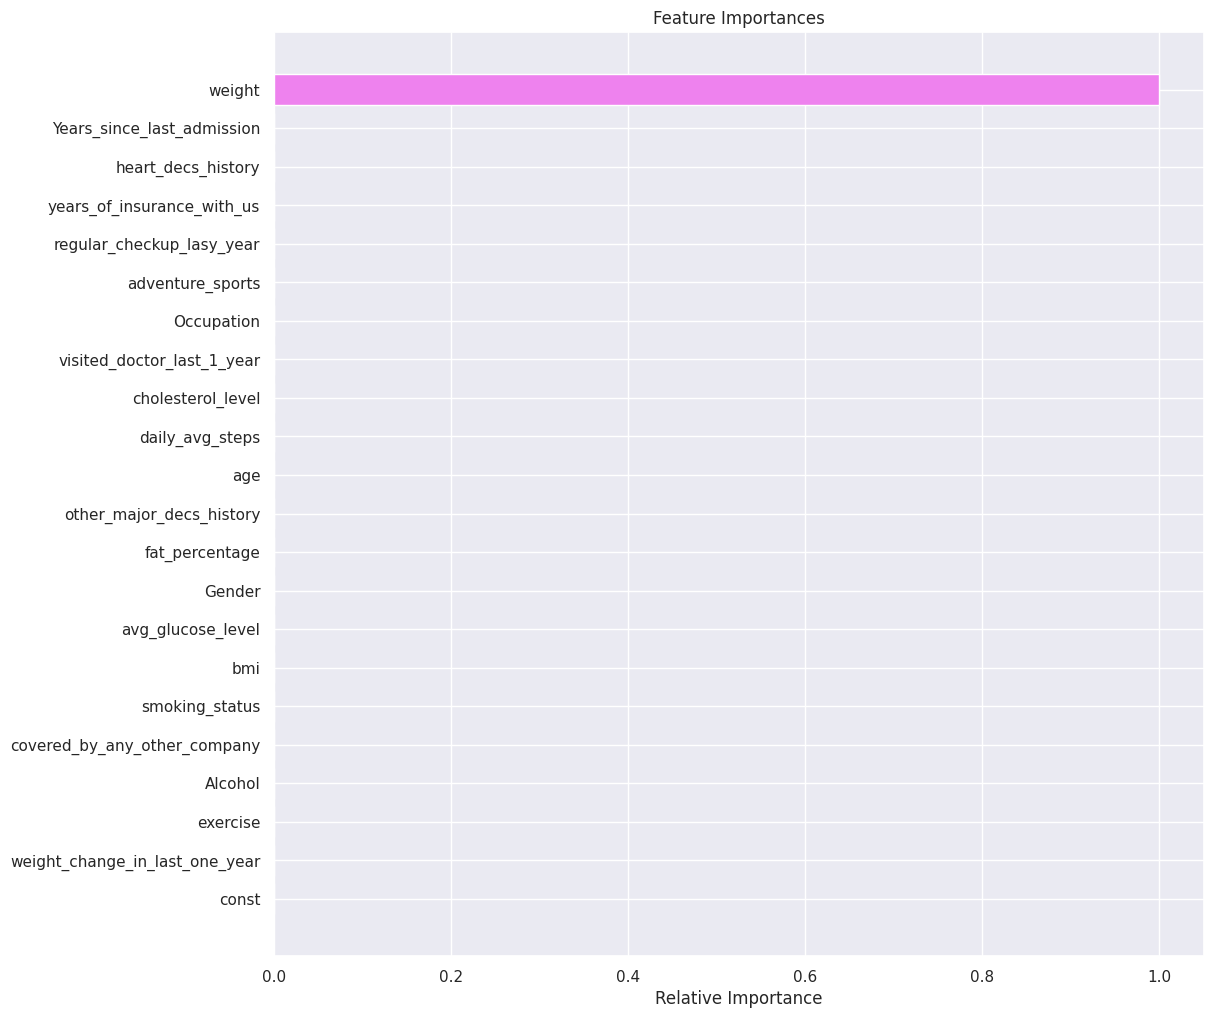

In [ ]:
feature_names = x_train.columns
importances = dtree_estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

- The tuned Decision Tree model has assigned importance only to the weight of the customer, indicating that other features were either not influential or were pruned during the tuning process.
- This suggests that, according to the model, body weight is the most significant predictor in determining the target variable. However, relying on a single feature might lead to a biased or overly simplistic model that ignores other potential influencing factors.
- To improve the model, it may be beneficial to re-evaluate feature selection, explore interaction effects between variables, or try alternative models like Random Forest or XGBoost, which consider multiple features and reduce bias.

## Bagging Regressor

In [ ]:
bagging = BaggingRegressor(random_state=1)

In [ ]:
# Train model
bagging.fit(x_train,y_train)

# Predictions
y_train_pred = bagging.predict(x_train)  # Predictions for training set
y_test_pred = bagging.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
Bagging_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
Bagging_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", Bagging_Train)
print("\n🔹 Test Set Metrics:", Bagging_Test)


🔹 Training Set Metrics: {'R²': 0.99, 'Adj. R²': 0.99, 'RMSE': 0.07, 'MAE': 0.04, 'MAPE (%)': 0.46}

🔹 Test Set Metrics: {'R²': 0.9404, 'Adj. R²': 0.9403, 'RMSE': 0.16, 'MAE': 0.12, 'MAPE (%)': 1.21}


#### Observation on Bagging Regressor Performance:

- The **Bagging Regressor shows strong performance** on both the training and test sets, with an **R² of 0.99 on training data** and **0.9404 on test data**, indicating a **highly predictive model** with minimal loss in generalization.  
- The **low RMSE (0.07 on training, 0.16 on test)** and **low MAE (0.04 on training, 0.12 on test)** suggest that the model's predictions are quite accurate, with small deviations from the actual values.  
- The **MAPE (%) of 0.46% on training and 1.21% on test** further confirms that the model has **high precision** and is able to generalize well.  
- Although there is **some performance drop between training and testing**, the gap is not extreme, indicating that the model is **not heavily overfitting** but still retains strong predictive capability.  
- Further improvements could involve **hyperparameter tuning** or **feature selection optimization** to further reduce the slight variance between training and test performance.

In [ ]:
# Extract feature importances for each tree in the Bagging ensemble
tree_importances = np.array([tree.feature_importances_ for tree in bagging.estimators_])

# Find the average importance (considering missing features)
mean_importances = np.mean(tree_importances, axis=0)

# Ensure the correct feature names are used
used_features = x_train.columns[: len(mean_importances)]

# Create a DataFrame
feature_importance_df = pd.DataFrame(
    mean_importances,
    index=used_features,
    columns=["Importance"]
).sort_values(by="Importance", ascending=False)

# Print feature importances
print(feature_importance_df)

                                Importance
weight                            0.932673
Years_since_last_admission        0.011459
weight_change_in_last_one_year    0.008015
bmi                               0.006645
daily_avg_steps                   0.006518
avg_glucose_level                 0.006332
age                               0.005565
fat_percentage                    0.004627
years_of_insurance_with_us        0.003513
regular_checkup_lasy_year         0.002306
visited_doctor_last_1_year        0.002035
smoking_status                    0.001735
covered_by_any_other_company      0.001695
cholesterol_level                 0.001690
exercise                          0.001300
Alcohol                           0.001185
Occupation                        0.001031
Gender                            0.000627
other_major_decs_history          0.000499
heart_decs_history                0.000319
adventure_sports                  0.000232
const                             0.000000


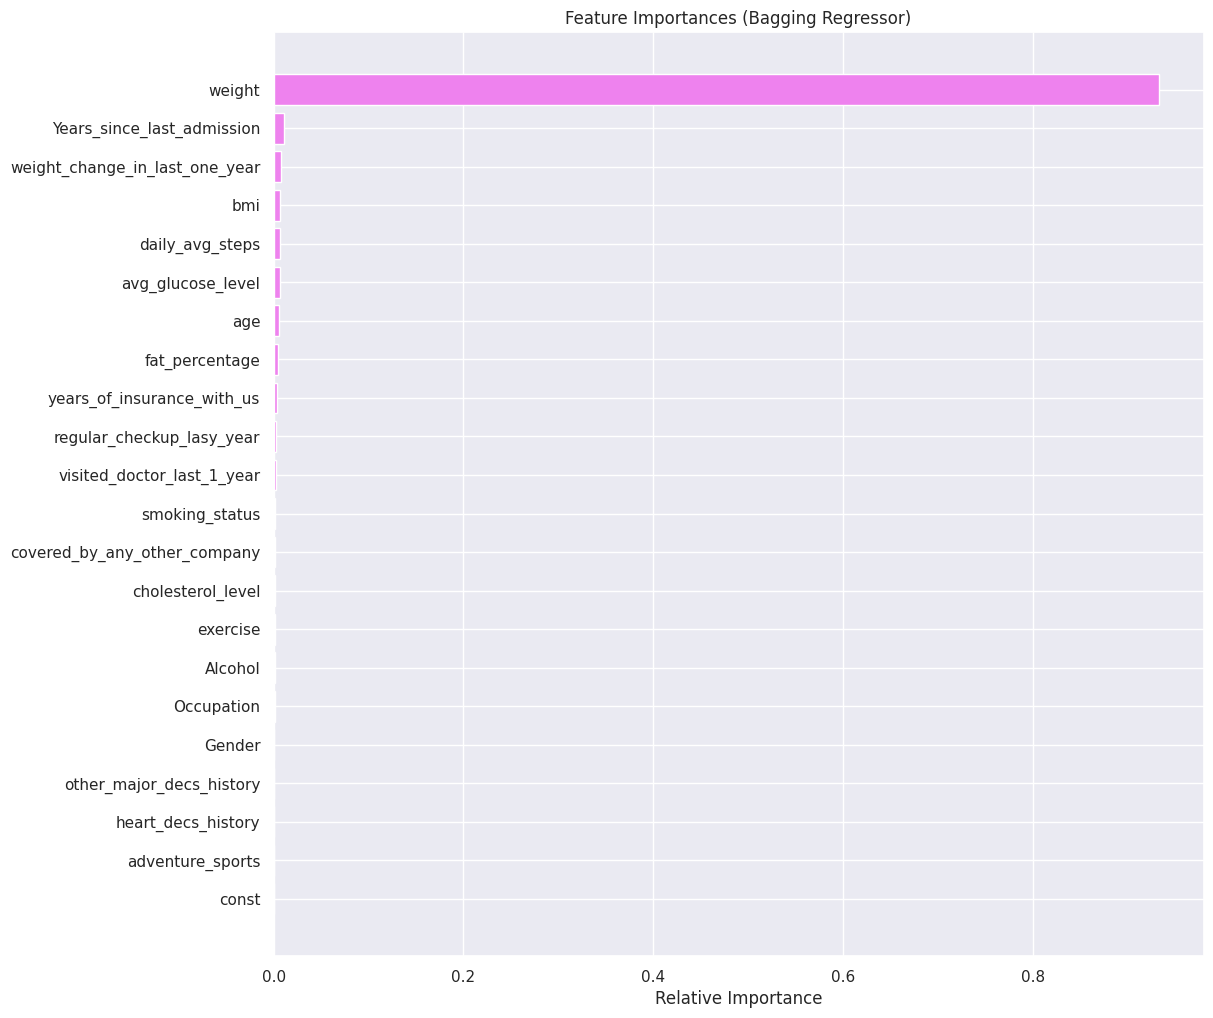

In [ ]:
# Extract feature importances from each decision tree in the Bagging ensemble
tree_importances = np.array([tree.feature_importances_ for tree in bagging.estimators_])

# Compute mean feature importance across all trees
mean_importances = np.mean(tree_importances, axis=0)

# Ensure correct feature alignment
feature_names = x_train.columns[: len(mean_importances)]
indices = np.argsort(mean_importances)  # Sort indices for visualization

# Plot feature importance
plt.figure(figsize=(12, 12))
plt.title('Feature Importances (Bagging Regressor)')
plt.barh(range(len(indices)), mean_importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

#### Feature Importance Analysis for Bagging Regressor:

- **Weight is the most influential variable**, contributing **93.27%** to the model's predictions, indicating that body weight is the primary determinant of the target variable.  
- **Years since last admission (1.15%)** and **weight change in the last year (0.8%)** have minor but notable importance, suggesting that recent health status and weight fluctuations impact the prediction.  
- **BMI (0.66%), daily average steps (0.65%), and average glucose level (0.63%)** play a small role, likely reflecting overall health and metabolic condition.  
- **Demographic factors like age (0.56%) and fat percentage (0.46%)** have marginal contributions, meaning they provide some predictive power but are not as critical.  
- **Lifestyle factors such as smoking status (0.17%), exercise (0.13%), and alcohol consumption (0.12%)** have very little influence, implying that their effect on the outcome is minimal in the model.  
- **Insurance-related features like years with the company (0.35%) and other coverage (0.16%)** are not significant predictors.  
- **Historical health conditions (heart disease history - 0.03%, major disease history - 0.05%) and adventure sports participation (0.02%)** have negligible contributions.  
- The **constant (bias term) has an importance score of zero**, meaning the model relies entirely on feature-based predictions rather than an inherent bias.

#### Tuning of Bagging Regressor

In [ ]:
# Define base Decision Tree Regressor
cl1 = DecisionTreeRegressor(criterion='squared_error', random_state=1)

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [5, 7, 15, 51, 101],  # Number of trees
    'max_features': [0.7, 0.8, 0.9, 1]  # Fraction of features to use per estimator
}

# Define GridSearchCV
grid = GridSearchCV(
    BaggingRegressor(estimator=cl1, random_state=1, bootstrap=True),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # RMSE (Negative because GridSearchCV minimizes)
    cv=5
)

# Fit grid search on training data
grid.fit(x_train, y_train)

# Get the best estimator
bagging_estimator_tuned = grid.best_estimator_

In [ ]:
# Train model
bagging_estimator_tuned.fit(x_train, y_train)

# Predictions
y_train_pred = bagging_estimator_tuned.predict(x_train)  # Predictions for training set
y_test_pred = bagging_estimator_tuned.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
Bagging_Estimator_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
Bagging_Estimator_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", Bagging_Estimator_Train)
print("\n🔹 Test Set Metrics:", Bagging_Estimator_Test)


🔹 Training Set Metrics: {'R²': 0.9912, 'Adj. R²': 0.9912, 'RMSE': 0.06, 'MAE': 0.05, 'MAPE (%)': 0.47}

🔹 Test Set Metrics: {'R²': 0.9419, 'Adj. R²': 0.9417, 'RMSE': 0.16, 'MAE': 0.12, 'MAPE (%)': 1.21}


####Observations on the Tuned Bagging Regressor Model:
-	**Model Performance**: The training R² is 0.9912, indicating that the model captures nearly all variance in the training data. However, the test R² is 0.9419, showing a slight performance drop, but the model still generalizes well.
-	**Error Metrics**: The RMSE (0.06 for training, 0.16 for testing) and MAE (0.05 for training, 0.12 for testing) suggest that while the model performs exceptionally well on training data, its performance on the test set is slightly lower, but still strong.
-	**Potential Overfitting**: The very high training R² suggests that the model might be slightly overfitting. However, since the test R² is also high, the model still generalizes well. Further tuning, such as adjusting the number of estimators or regularization, might improve generalizability.
-	**MAPE (%) Comparison**: The mean absolute percentage error (MAPE) remains low (0.47% in training, 1.21% in testing), confirming that the model makes accurate predictions with minimal percentage errors.

Overall, the tuned Bagging Regressor performs slightly better than the untuned version, maintaining strong generalization with only a minor risk of overfitting.


In [ ]:
# Extract feature importances for each tree in the Bagging ensemble
tree_importances = np.array([tree.feature_importances_ for tree in bagging_estimator_tuned.estimators_])

# Find the average importance (considering missing features)
mean_importances = np.mean(tree_importances, axis=0)

# Ensure the correct feature names are used
used_features = x_train.columns[: len(mean_importances)]

# Create a DataFrame
feature_importance_df = pd.DataFrame(
    mean_importances,
    index=used_features,
    columns=["Importance"]
).sort_values(by="Importance", ascending=False)

# Print feature importances
print(feature_importance_df)

                              Importance
avg_glucose_level               0.116656
heart_decs_history              0.096361
bmi                             0.084928
Occupation                      0.084616
years_of_insurance_with_us      0.079693
adventure_sports                0.066450
covered_by_any_other_company    0.065697
visited_doctor_last_1_year      0.060329
smoking_status                  0.057513
cholesterol_level               0.050988
Gender                          0.042493
exercise                        0.041579
const                           0.028899
age                             0.026643
daily_avg_steps                 0.025499
regular_checkup_lasy_year       0.025062
weight                          0.022661
other_major_decs_history        0.013271
Alcohol                         0.010662


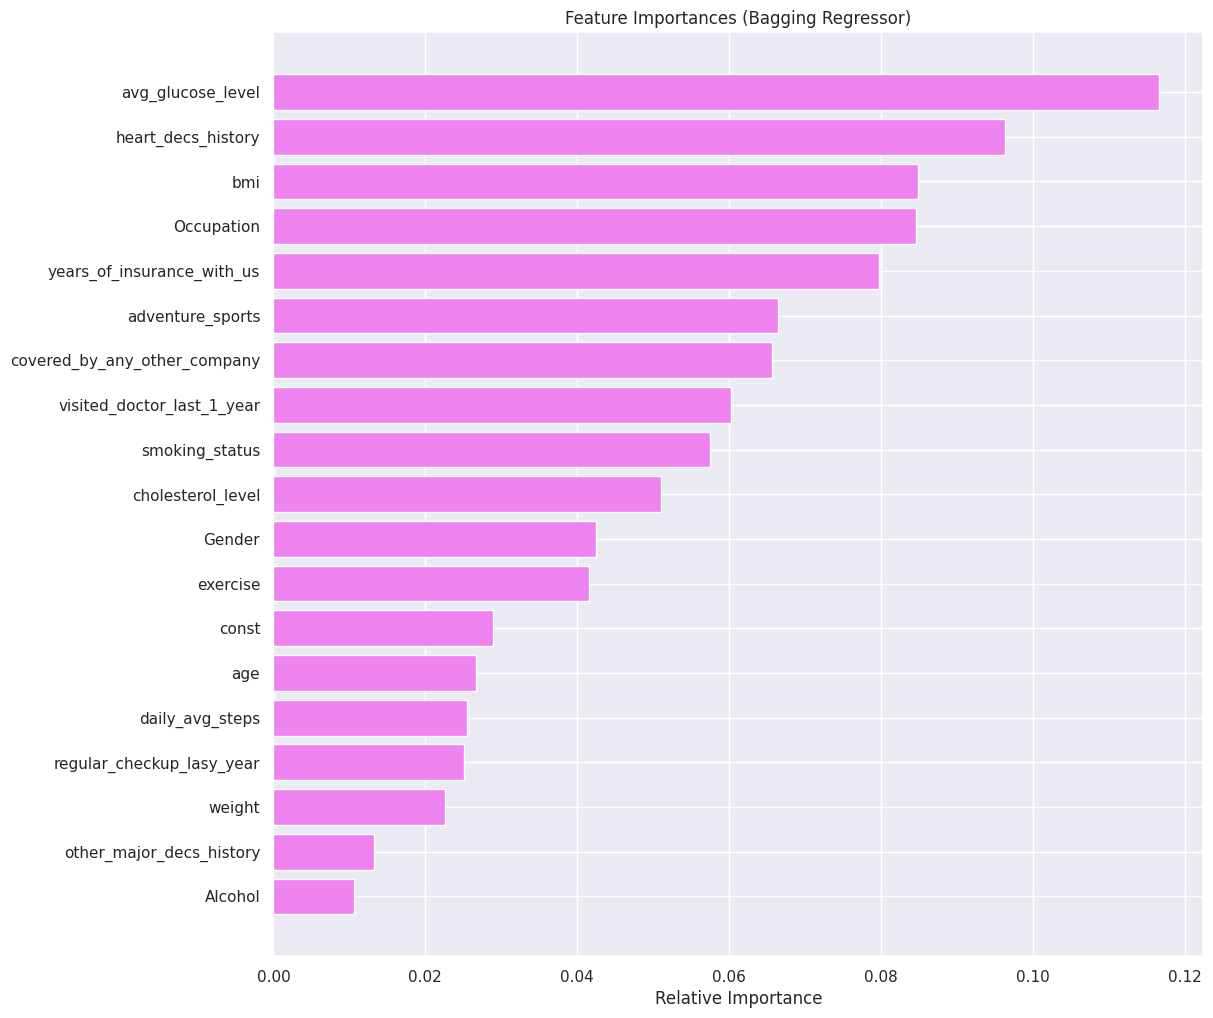

In [ ]:
# Extract feature importances from each decision tree in the Bagging ensemble
tree_importances = np.array([tree.feature_importances_ for tree in bagging_estimator_tuned.estimators_])

# Compute mean feature importance across all trees
mean_importances = np.mean(tree_importances, axis=0)

# Ensure correct feature alignment
feature_names = x_train.columns[: len(mean_importances)]
indices = np.argsort(mean_importances)  # Sort indices for visualization

# Plot feature importance
plt.figure(figsize=(12, 12))
plt.title('Feature Importances (Bagging Regressor)')
plt.barh(range(len(indices)), mean_importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

#### Observations on Feature Importance Tuned Bagging Regressor:
- In earlier models (such as Decision Tree and Bagging Regressor), Weight was the dominant feature. However, in this model, Avg_glucose_level and Heart_disease_history have taken precedence.
- The feature distribution appears more balanced, meaning the model considers multiple factors rather than relying too heavily on a single variable.
- Unlike the Decision Tree model, where only weight was a key factor, this model distributes importance across health metrics, medical history, and lifestyle factors.

## Random Forest

In [ ]:
rf = RandomForestRegressor(random_state=1)

In [ ]:
# Train model
rf.fit(x_train,y_train)

# Predictions
y_train_pred = rf.predict(x_train)  # Predictions for training set
y_test_pred = rf.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
RF_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
RF_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", RF_Train)
print("\n🔹 Test Set Metrics:", RF_Test)


🔹 Training Set Metrics: {'R²': 0.9926, 'Adj. R²': 0.9926, 'RMSE': 0.06, 'MAE': 0.04, 'MAPE (%)': 0.43}

🔹 Test Set Metrics: {'R²': 0.9459, 'Adj. R²': 0.9458, 'RMSE': 0.15, 'MAE': 0.11, 'MAPE (%)': 1.15}


####**Observations on Random Forest Model Performance:**
Training Set Performance:
-	R² = 0.9926 and Adj. R² = 0.9926 indicate an excellent fit on the training data, showing that the model explains nearly all the variability in the target variable.
-	RMSE (0.06) and MAE (0.04) are very low, suggesting minimal prediction errors.
-	The MAPE (0.43%) is impressively low, indicating highly accurate percentage error predictions.

Test Set Performance:
-	R² = 0.9459 and Adj. R² = 0.9458 highlight strong predictive performance on unseen data, showing the model generalizes well.
-	RMSE (0.15) and MAE (0.11) remain low, confirming good predictive accuracy.
-	The MAPE (1.15%) indicates strong percentage error control on test data.

Key Observations:
-	The model demonstrates excellent performance with minimal signs of overfitting. The slight performance gap between the training and test sets (R² drop from 0.9926 to 0.9459) is expected in real-world scenarios.
-	Compared to the Tuned Bagging Regressor (R² = 0.9419), the Random Forest model shows improved test set performance.
-	The model balances both low error rates and strong predictive accuracy, making it a robust choice for your regression task.


In [ ]:
# importance of features in the tree building

print(pd.DataFrame(rf.feature_importances_, columns = ["Imp"], index = x_train.columns).sort_values(by = 'Imp', ascending = False))

                                    Imp
weight                         0.933189
Years_since_last_admission     0.011246
weight_change_in_last_one_year 0.008054
daily_avg_steps                0.006691
bmi                            0.006549
avg_glucose_level              0.006213
age                            0.005538
fat_percentage                 0.004563
years_of_insurance_with_us     0.003407
regular_checkup_lasy_year      0.002230
visited_doctor_last_1_year     0.002044
smoking_status                 0.001723
covered_by_any_other_company   0.001653
cholesterol_level              0.001647
exercise                       0.001337
Alcohol                        0.001141
Occupation                     0.001012
Gender                         0.000618
other_major_decs_history       0.000534
heart_decs_history             0.000325
adventure_sports               0.000285
const                          0.000000


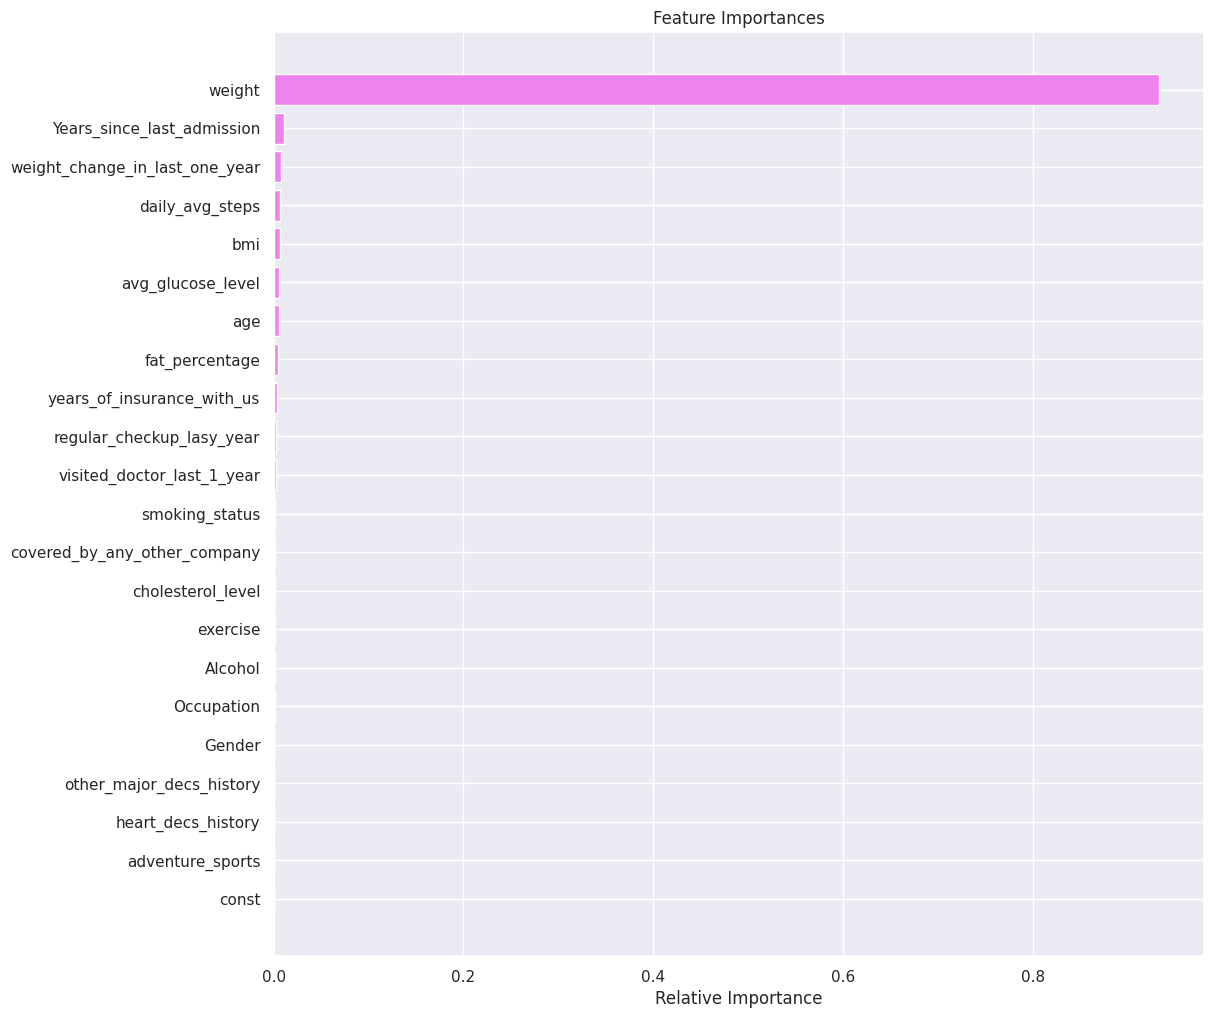

In [ ]:
feature_names = x_train.columns
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

####**Observations on Feature Importance for the Random Forest Model:**
-	Dominating Feature:
    - Weight (Importance = 0.933) is overwhelmingly the most influential factor in the model, indicating it plays a crucial role in predicting the target variable. This dominance suggests the target variable has a strong dependency on body weight.
-	Moderate Influence Features:
  -	Features like Years_since_last_admission (0.011), weight_change_in_last_one_year (0.008), and daily_avg_steps (0.0067) contribute moderately, implying these factors still have a meaningful impact but are far less significant compared to weight.
-	Low Influence Features:
  - Variables such as cholesterol_level, exercise, and Alcohol have minimal importance, indicating limited contribution to the model's predictive power.
-	Negligible Influence Features:
  -	Features like heart_decs_history, adventure_sports, and other_major_decs_history have extremely low importance values, suggesting they have minimal or no impact on the model’s performance.

Key Takeaways:
- The model heavily relies on weight, which may indicate potential data imbalance or a strong correlation with the target variable.
- Although some lifestyle factors (e.g., exercise, alcohol) appear less impactful, they might still provide indirect insights when combined with other variables.
- Consider examining multicollinearity or performing further feature engineering to assess if less important variables can be refined or merged to enhance model performance.

#### Tuning of RF

In [ ]:
# Choose the type of classifier.
rf_estimator_tuned = RandomForestRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {
        "n_estimators": [110,251,501],
        "min_samples_leaf": np.arange(1, 6,1),
        "max_features": [0.7,0.9,'log2','auto'],
        "max_samples": [0.7,0.9,None],
}

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring='recall',cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_estimator_tuned.fit(x_train, y_train)

RandomForestRegressor(max_features=0.7, max_samples=0.7, n_estimators=110,
                      random_state=1)

In [ ]:
# Train model
rf_estimator_tuned.fit(x_train, y_train)

# Predictions
y_train_pred = rf_estimator_tuned.predict(x_train)  # Predictions for training set
y_test_pred = rf_estimator_tuned.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100



# Store Training Set Results
RF_Estimator_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
RF_Estimator_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", RF_Estimator_Train)
print("\n🔹 Test Set Metrics:", RF_Estimator_Test)


🔹 Training Set Metrics: {'R²': 0.9869, 'Adj. R²': 0.9869, 'RMSE': 0.08, 'MAE': 0.06, 'MAPE (%)': 0.57}

🔹 Test Set Metrics: {'R²': 0.9474, 'Adj. R²': 0.9472, 'RMSE': 0.15, 'MAE': 0.11, 'MAPE (%)': 1.14}


**Observations on Tuned Random Forest Model Performance:**
- Training Set Performance:

   - The model demonstrates excellent performance on the training data with an R² of 0.9869 and minimal errors (RMSE = 0.08, MAE = 0.06, MAPE = 0.57%).

   - Such strong metrics suggest the model effectively fits the training data, capturing complex patterns well.

- Test Set Performance:

    - The model maintains strong generalization on unseen data with an R² of 0.9474, indicating that about 94.7% of the variance in the target variable is explained by the model.
    - The error metrics (RMSE = 0.15, MAE = 0.11, MAPE = 1.14%) are reasonably low, showcasing good predictive accuracy.

- Key Observations:
    - The slight gap between training and test scores suggests the model has achieved a balance between accuracy and generalization, minimizing overfitting.
    - Despite the improved performance after tuning, the dominance of weight in feature importance may still indicate a potential imbalance in variable influence.
    - The model’s low MAPE (%) highlights its robustness in predicting relative percentage errors, making it particularly suitable for continuous value predictions in your data.

In [ ]:
# importance of features in the tree building

print(pd.DataFrame(rf_estimator_tuned.feature_importances_, columns = ["Imp"], index = x_train.columns).sort_values(by = 'Imp', ascending = False))

                                    Imp
weight                         0.817060
Years_since_last_admission     0.092130
weight_change_in_last_one_year 0.037473
years_of_insurance_with_us     0.007557
daily_avg_steps                0.006462
bmi                            0.006435
avg_glucose_level              0.006193
age                            0.005685
fat_percentage                 0.004587
regular_checkup_lasy_year      0.003360
visited_doctor_last_1_year     0.002065
smoking_status                 0.001812
covered_by_any_other_company   0.001763
cholesterol_level              0.001748
exercise                       0.001372
Alcohol                        0.001243
Occupation                     0.001059
Gender                         0.000673
other_major_decs_history       0.000604
adventure_sports               0.000361
heart_decs_history             0.000355
const                          0.000000


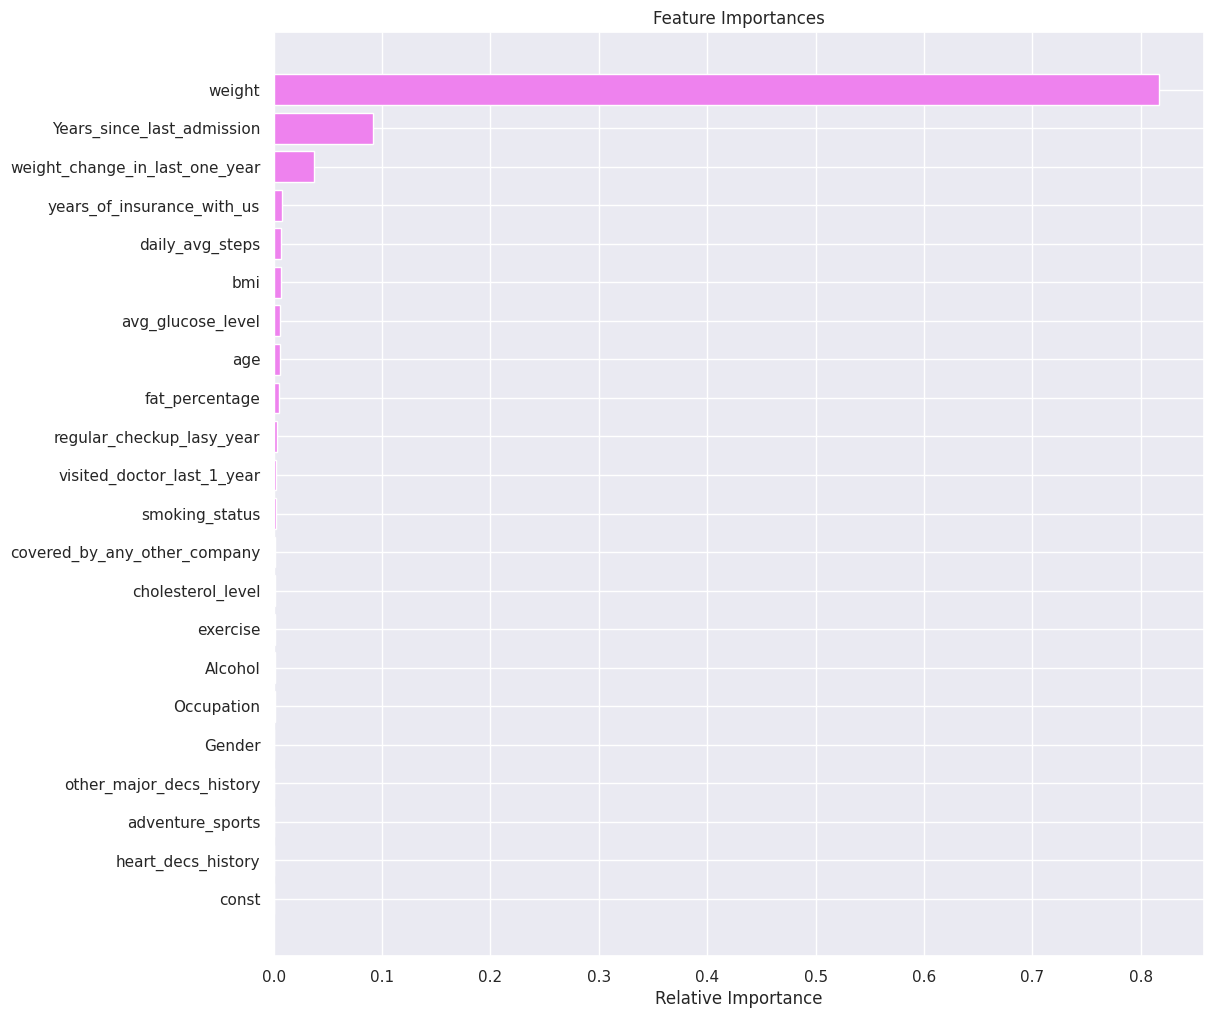

In [ ]:
feature_names = x_train.columns
importances = rf_estimator_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

#### **Observations on Tuned Random Forest Feature Importance:**
- Key Variable Dominance:

  - The weight variable has the highest importance (0.81706) by a significant margin, suggesting it is the primary driver of the model’s predictions. This heavy reliance could indicate potential overfitting or data imbalance.

- Secondary Influencers:

  - Years since last admission (0.09213) is the second most influential feature, followed by weight change in the last one year (0.03747). These variables may reflect key health patterns relevant to the prediction target.

- Marginal Contributors:

  - Variables like age, BMI, glucose levels, and fat percentage contribute minimally, yet they still provide some predictive value.
  -  Features such as heart disease history, adventure sports, and gender have very low importance values, indicating limited influence on model outcomes.

## Boosting Technique Regression

### AdaBoost Regressor

In [ ]:
ab_Regressor=AdaBoostRegressor(random_state=1)

In [ ]:
# Train model
ab_Regressor.fit(x_train,y_train)

# Predictions
y_train_pred = ab_Regressor.predict(x_train)  # Predictions for training set
y_test_pred = ab_Regressor.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
AdaBoost_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
AdaBoost_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", AdaBoost_Train)
print("\n🔹 Test Set Metrics:", AdaBoost_Test)


🔹 Training Set Metrics: {'R²': 0.9333, 'Adj. R²': 0.9332, 'RMSE': 0.17, 'MAE': 0.13, 'MAPE (%)': 1.33}

🔹 Test Set Metrics: {'R²': 0.9333, 'Adj. R²': 0.9331, 'RMSE': 0.17, 'MAE': 0.13, 'MAPE (%)': 1.32}


#### **Observations on Simple AdaBoost Model Performance:**
- Strong Model Performance:

   - The AdaBoost model demonstrates consistent performance across both training and test sets with an R² of 0.9333, indicating that the model explains 93.3% of the variance in the target variable. This suggests the model has learned the data patterns effectively.
- Error Metrics Analysis:

    - The RMSE value of 0.17 for both the training and test sets reflects a moderate prediction error, indicating a reasonable fit with stable performance.
    - The MAE value of 0.13 and MAPE of ~1.3% further confirm low deviation between predicted and actual values, signifying the model's precision.
- Balanced Performance:

    - The similarity between training and test metrics suggests low risk of overfitting, implying the model generalizes well to unseen data.

In [ ]:
# importance of features in the tree building

print(pd.DataFrame(ab_Regressor.feature_importances_, columns = ["Imp"], index = x_train.columns).sort_values(by = 'Imp', ascending = False))

                                    Imp
weight                         0.932807
Years_since_last_admission     0.029073
weight_change_in_last_one_year 0.012859
years_of_insurance_with_us     0.010991
regular_checkup_lasy_year      0.010874
age                            0.003395
bmi                            0.000000
fat_percentage                 0.000000
exercise                       0.000000
Alcohol                        0.000000
covered_by_any_other_company   0.000000
smoking_status                 0.000000
const                          0.000000
avg_glucose_level              0.000000
other_major_decs_history       0.000000
heart_decs_history             0.000000
daily_avg_steps                0.000000
cholesterol_level              0.000000
visited_doctor_last_1_year     0.000000
Occupation                     0.000000
adventure_sports               0.000000
Gender                         0.000000


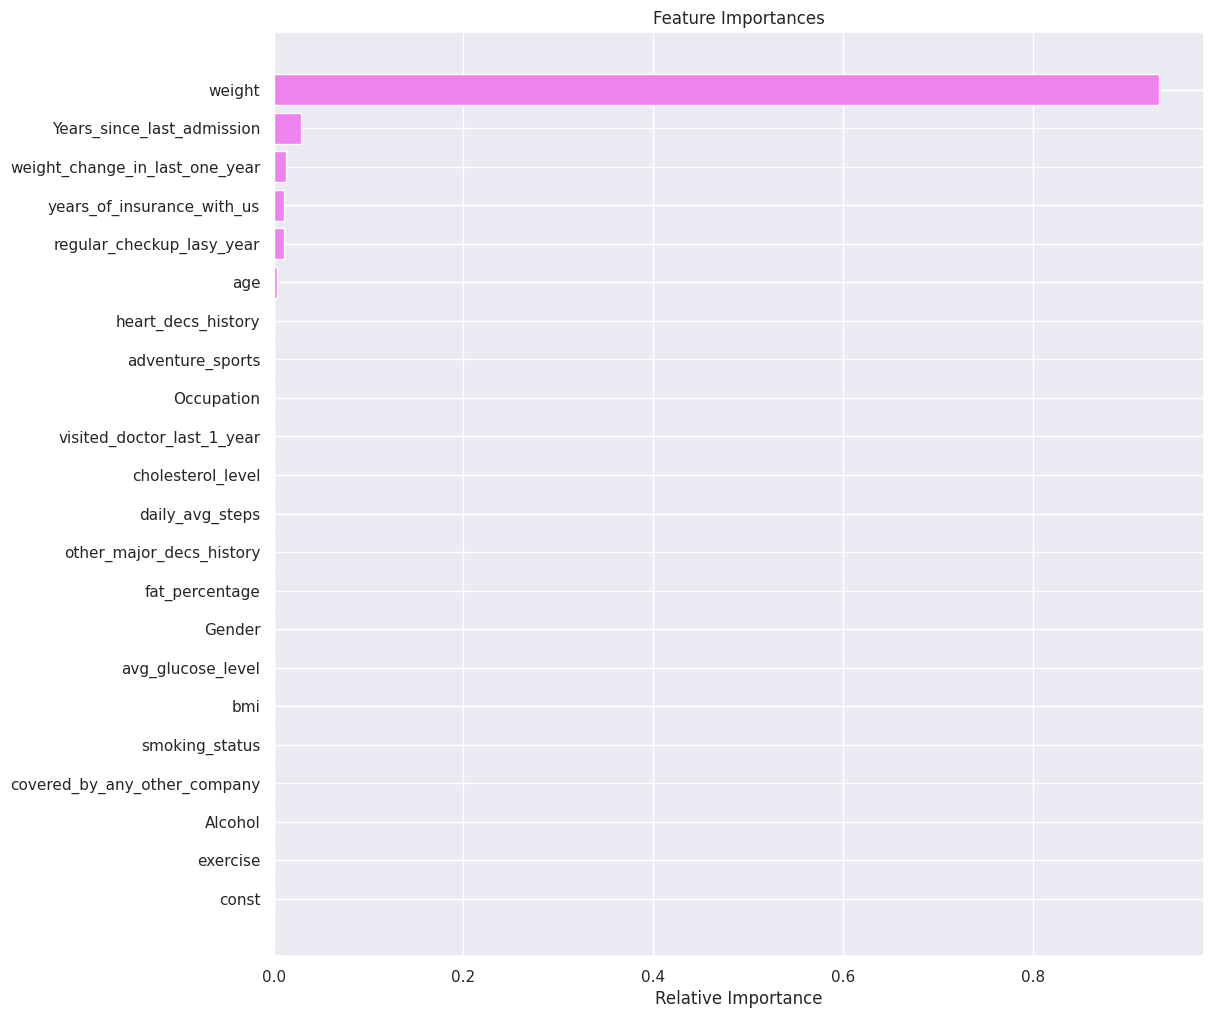

In [ ]:
feature_names = x_train.columns
importances = ab_Regressor.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

####**Observations on Simple AdaBoost Feature Importance:**
- Dominance of Key Features:

    - The AdaBoost model has placed overwhelming importance on the weight variable (0.9328), suggesting that weight is the primary factor driving predictions.
- Secondary contributors include:
    - Years since last admission (0.029)
    - Weight change in the last one year (0.0129)
    - Years of insurance with us (0.011)
    - Regular checkup in the last year (0.0109)
- Negligible or Zero Importance for Many Features:

    - Several variables, such as BMI, exercise, alcohol, and cholesterol level, show zero importance, meaning the AdaBoost model deemed them irrelevant for prediction.

- Potential Overfitting Risk:

    - The extreme focus on a single feature (weight) might indicate an overfitting issue, where the model relies too heavily on one dominant factor. This may reduce its ability to generalize well in different scenarios.

#### Tuning of AdaBoosting

In [ ]:
# Choose the type of classifier.
ab_tuned = AdaBoostRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {'n_estimators': np.arange(10,100,10),
              'learning_rate': [1, 0.1, 0.5, 0.01],
              }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(ab_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
ab_tuned = grid_obj.best_estimator_

In [ ]:
# Fit the best algorithm to the data.
ab_tuned.fit(x_train, y_train)

# Predictions
y_train_pred = ab_tuned.predict(x_train)  # Predictions for training set
y_test_pred = ab_tuned.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
AdaBoost_Estimator_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
AdaBoost_Estimator_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", AdaBoost_Estimator_Train)
print("\n🔹 Test Set Metrics:", AdaBoost_Estimator_Test)


🔹 Training Set Metrics: {'R²': 0.9323, 'Adj. R²': 0.9322, 'RMSE': 0.17, 'MAE': 0.13, 'MAPE (%)': 1.34}

🔹 Test Set Metrics: {'R²': 0.9322, 'Adj. R²': 0.932, 'RMSE': 0.17, 'MAE': 0.13, 'MAPE (%)': 1.33}


####**Observations on Tuned AdaBoost Model Performance:**
- Model Performance Analysis:
    - The training and test metrics are very similar, indicating that the model has achieved good generalization without significant overfitting or underfitting.
    - The R² values for both sets (~0.93) demonstrate strong predictive accuracy, though slightly lower than some other models like Random Forest or Bagging.
    - RMSE, MAE, and MAPE values are also consistent across both sets, reinforcing stable model behavior.
- Strengths:
    - The model maintains consistent performance across training and test data.
    - The model effectively balances bias and variance, ensuring predictions are stable.
- Limitations:
    - Despite stable performance, the model's R² score is slightly lower than models like Random Forest or Bagging, suggesting that AdaBoost may have sacrificed some predictive power in exchange for stability.
    - As seen from the feature importance analysis, the model heavily emphasizes a single dominant feature (weight), which may reduce adaptability to unseen data.

In [ ]:
# importance of features in the tree building

print(pd.DataFrame(ab_tuned.feature_importances_, columns = ["Imp"], index = x_train.columns).sort_values(by = 'Imp', ascending = False))

                                    Imp
weight                         0.934838
Years_since_last_admission     0.032826
weight_change_in_last_one_year 0.017449
years_of_insurance_with_us     0.007629
regular_checkup_lasy_year      0.005648
age                            0.001609
bmi                            0.000000
fat_percentage                 0.000000
exercise                       0.000000
Alcohol                        0.000000
covered_by_any_other_company   0.000000
smoking_status                 0.000000
const                          0.000000
avg_glucose_level              0.000000
other_major_decs_history       0.000000
heart_decs_history             0.000000
daily_avg_steps                0.000000
cholesterol_level              0.000000
visited_doctor_last_1_year     0.000000
Occupation                     0.000000
adventure_sports               0.000000
Gender                         0.000000


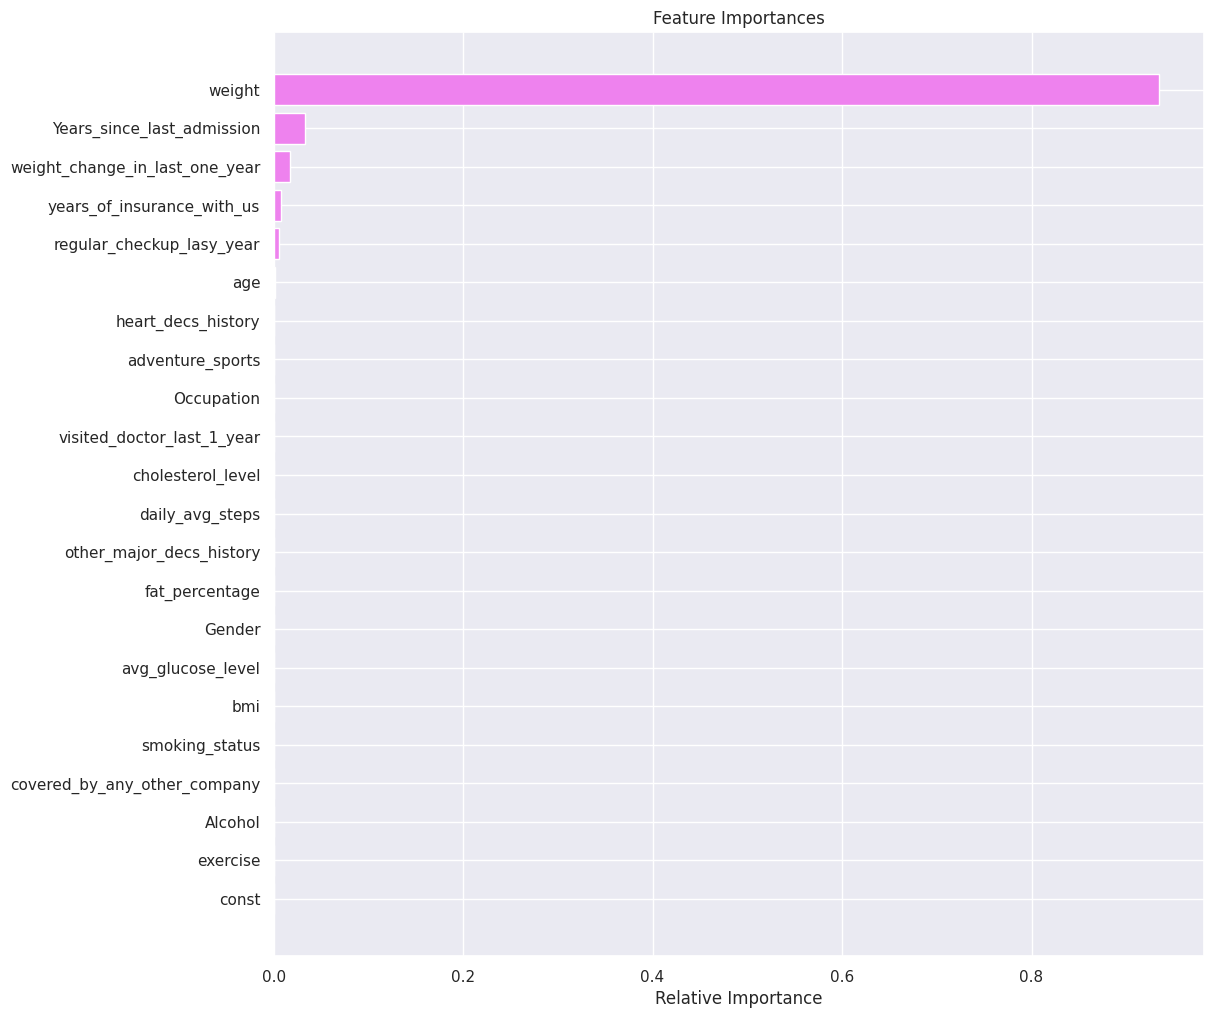

In [ ]:
feature_names = x_train.columns
importances = ab_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

####**Observations on Feature Importance (Tuned AdaBoost Model):**
- Dominant Feature:

    - The model assigns extremely high importance to 'weight' (0.9348), indicating that this variable overwhelmingly drives the model's predictions. This heavy reliance may suggest the model is overly dependent on this feature, potentially limiting its robustness in diverse scenarios.
- Moderately Important Features:

   - Features like 'Years_since_last_admission' (0.0328) and 'weight_change_in_last_one_year' (0.0174) provide some additional predictive value but are significantly less influential than 'weight'.
- Minimal Contribution Features:

    - Variables such as 'years_of_insurance_with_us', 'regular_checkup_last_year', and 'age' have minimal impact.
    - All other features, including 'bmi', 'exercise', and 'cholesterol_level', contribute zero importance to the model.


### Gradient boosting

In [ ]:
gb_estimator=GradientBoostingRegressor(random_state=1)

In [ ]:
# Train model
gb_estimator.fit(x_train,y_train)

# Predictions
y_train_pred = gb_estimator.predict(x_train)  # Predictions for training set
y_test_pred = gb_estimator.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
GB_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
GB_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", GB_Train)
print("\n🔹 Test Set Metrics:", GB_Test)


🔹 Training Set Metrics: {'R²': 0.95, 'Adj. R²': 0.9499, 'RMSE': 0.15, 'MAE': 0.11, 'MAPE (%)': 1.12}

🔹 Test Set Metrics: {'R²': 0.9483, 'Adj. R²': 0.9481, 'RMSE': 0.15, 'MAE': 0.11, 'MAPE (%)': 1.14}


####**Observations on Gradient Boosting Model Performance:**
- Strong Overall Performance:

   - The model shows excellent predictive accuracy with an R² of 0.95 on the training set and 0.9483 on the test set, indicating minimal overfitting.
   - The Adjusted R² values (0.9499 for training and 0.9481 for test) confirm that the model generalizes well without relying too heavily on excessive predictors.
- Error Metrics:

   - The RMSE values of 0.15 for both sets indicate a consistently low prediction error, reinforcing the model's reliability.
   - The MAE values of 0.11 highlight the model’s strong ability to predict individual data points with minimal deviation.
   - The MAPE (%) values (1.12% for training, 1.14% for test) demonstrate that the model maintains excellent predictive accuracy across varying scales.
- Balanced Model:

  - The negligible difference between the training and test metrics indicates that the model is well-tuned and avoids overfitting.


In [ ]:
# importance of features in the tree building

print(pd.DataFrame(gb_estimator.feature_importances_, columns = ["Imp"], index = x_train.columns).sort_values(by = 'Imp', ascending = False))

                                    Imp
weight                         0.979744
Years_since_last_admission     0.011446
weight_change_in_last_one_year 0.005977
covered_by_any_other_company   0.001146
regular_checkup_lasy_year      0.000805
years_of_insurance_with_us     0.000490
daily_avg_steps                0.000120
age                            0.000070
avg_glucose_level              0.000066
bmi                            0.000042
fat_percentage                 0.000034
exercise                       0.000013
adventure_sports               0.000010
visited_doctor_last_1_year     0.000009
other_major_decs_history       0.000008
Occupation                     0.000006
cholesterol_level              0.000006
heart_decs_history             0.000005
Alcohol                        0.000002
const                          0.000000
smoking_status                 0.000000
Gender                         0.000000


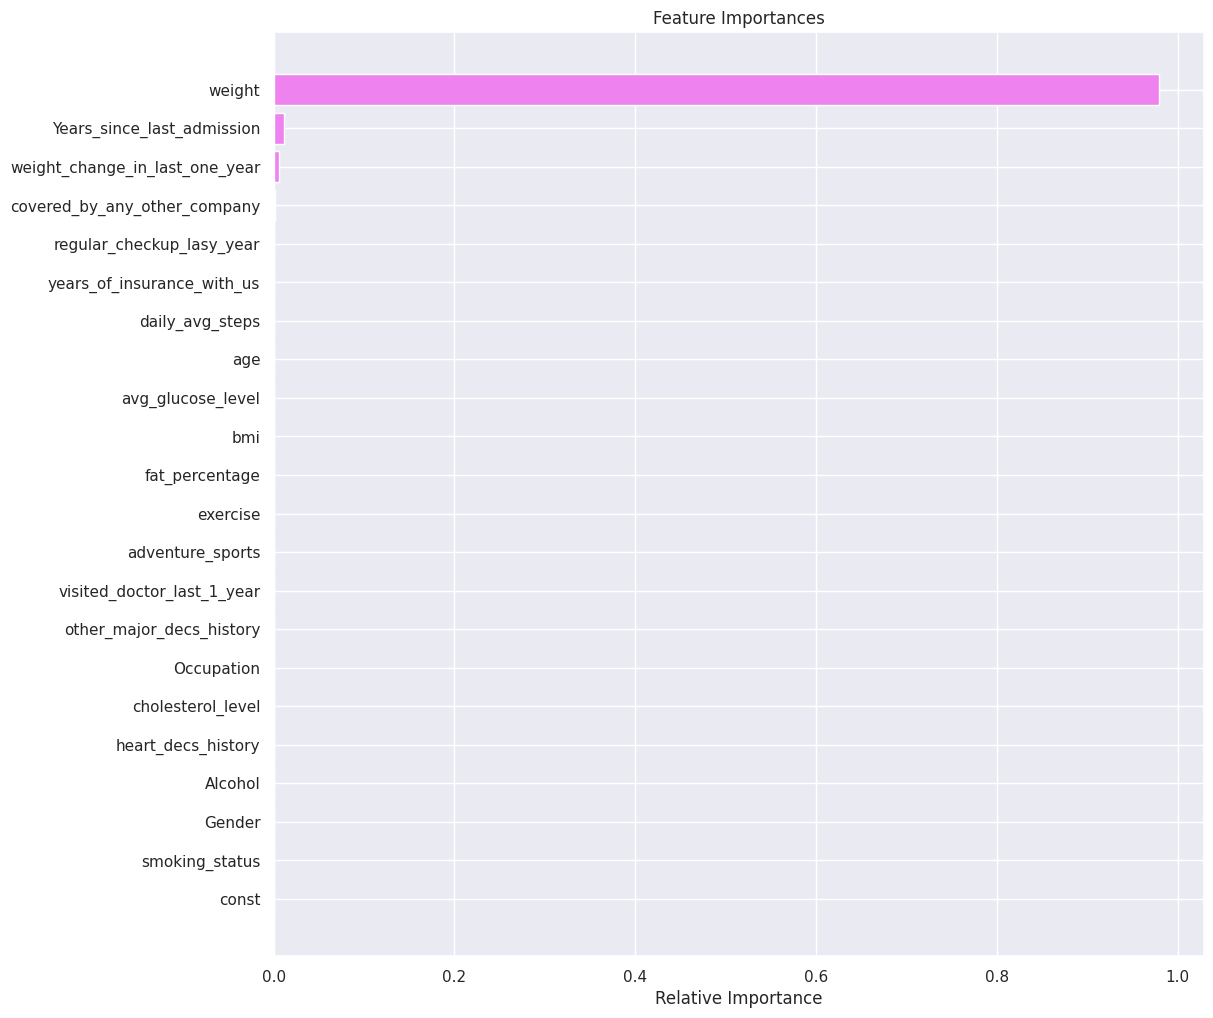

In [ ]:
feature_names = x_train.columns
importances = gb_estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

####**Observations on Gradient Boosting Feature Importance**
- Key Dominating Feature:
  -	Weight is by far the most influential feature, with an importance score of 0.9797, indicating it plays a major role in the model’s predictions. This suggests that weight has a significant impact on the target variable.
- Moderate Influence Features:
  - Years since last admission (0.0114) and Weight change in the last one year (0.0059) contribute moderately to the model's predictive power. These features may relate to health stability and recent lifestyle changes.
- Minimal Contribution Features:
  - Features such as Covered by any other company, Regular checkup last year, and Years of insurance with us have minor influence but may still hold some predictive value.
  - Several features like Alcohol, Smoking Status, and Gender have zero importance, suggesting they had no measurable impact on the model’s performance.


#### Tuning of Gradient Boosting

In [ ]:
# Choose the type of classifier.
gb_tuned = GradientBoostingRegressor(random_state=1)

# Grid of parameters to choose from
parameters = {'n_estimators': np.arange(50,200,25),
              'subsample':[0.7,0.8,0.9,1],
              'max_features':[0.7,0.8,0.9,1],
              'max_depth':[3,5,7,10]
              }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(gb_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
gb_tuned = grid_obj.best_estimator_


In [ ]:
# Fit the best algorithm to the data.
gb_tuned.fit(x_train, y_train)

# Predictions
y_train_pred = gb_tuned.predict(x_train)  # Predictions for training set
y_test_pred = gb_tuned.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
GB_Tuned_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
GB_Tuned_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", GB_Tuned_Train)
print("\n🔹 Test Set Metrics:", GB_Tuned_Test)


🔹 Training Set Metrics: {'R²': 0.9557, 'Adj. R²': 0.9557, 'RMSE': 0.14, 'MAE': 0.1, 'MAPE (%)': 1.06}

🔹 Test Set Metrics: {'R²': 0.949, 'Adj. R²': 0.9489, 'RMSE': 0.15, 'MAE': 0.11, 'MAPE (%)': 1.13}


Observations on Tuned Gradient Boosting Model
- Performance Improvements:
    - The Training R² improved to 0.9557, indicating a stronger fit to the training data.
    - The Test R² improved slightly to 0.949, reflecting better generalization.
- Error Metrics Analysis:
    - The RMSE reduced to 0.14 in the training set and 0.15 in the test set, demonstrating improved accuracy.
    - The MAE dropped to 0.10 for training and 0.11 for testing, further confirming better prediction precision.
    - The MAPE (%) values improved to 1.06% in training and 1.13% in testing, indicating stronger reliability across varying target values.
- Key Observations:
    - The reduced gap between the training and test scores suggests the model has effectively balanced bias and variance, reducing the risk of overfitting.
    - The model maintains a high predictive power while improving generalization, which is crucial for real-world applications.


In [ ]:
# importance of features in the tree building

print(pd.DataFrame(gb_tuned.feature_importances_, columns = ["Imp"], index = x_train.columns).sort_values(by = 'Imp', ascending = False))

                                    Imp
weight                         0.902402
Years_since_last_admission     0.061199
weight_change_in_last_one_year 0.021682
years_of_insurance_with_us     0.008039
covered_by_any_other_company   0.001612
regular_checkup_lasy_year      0.001184
daily_avg_steps                0.000928
bmi                            0.000627
avg_glucose_level              0.000569
fat_percentage                 0.000528
age                            0.000467
cholesterol_level              0.000146
visited_doctor_last_1_year     0.000123
exercise                       0.000117
Occupation                     0.000100
other_major_decs_history       0.000084
smoking_status                 0.000079
Alcohol                        0.000055
heart_decs_history             0.000028
adventure_sports               0.000024
Gender                         0.000006
const                          0.000000


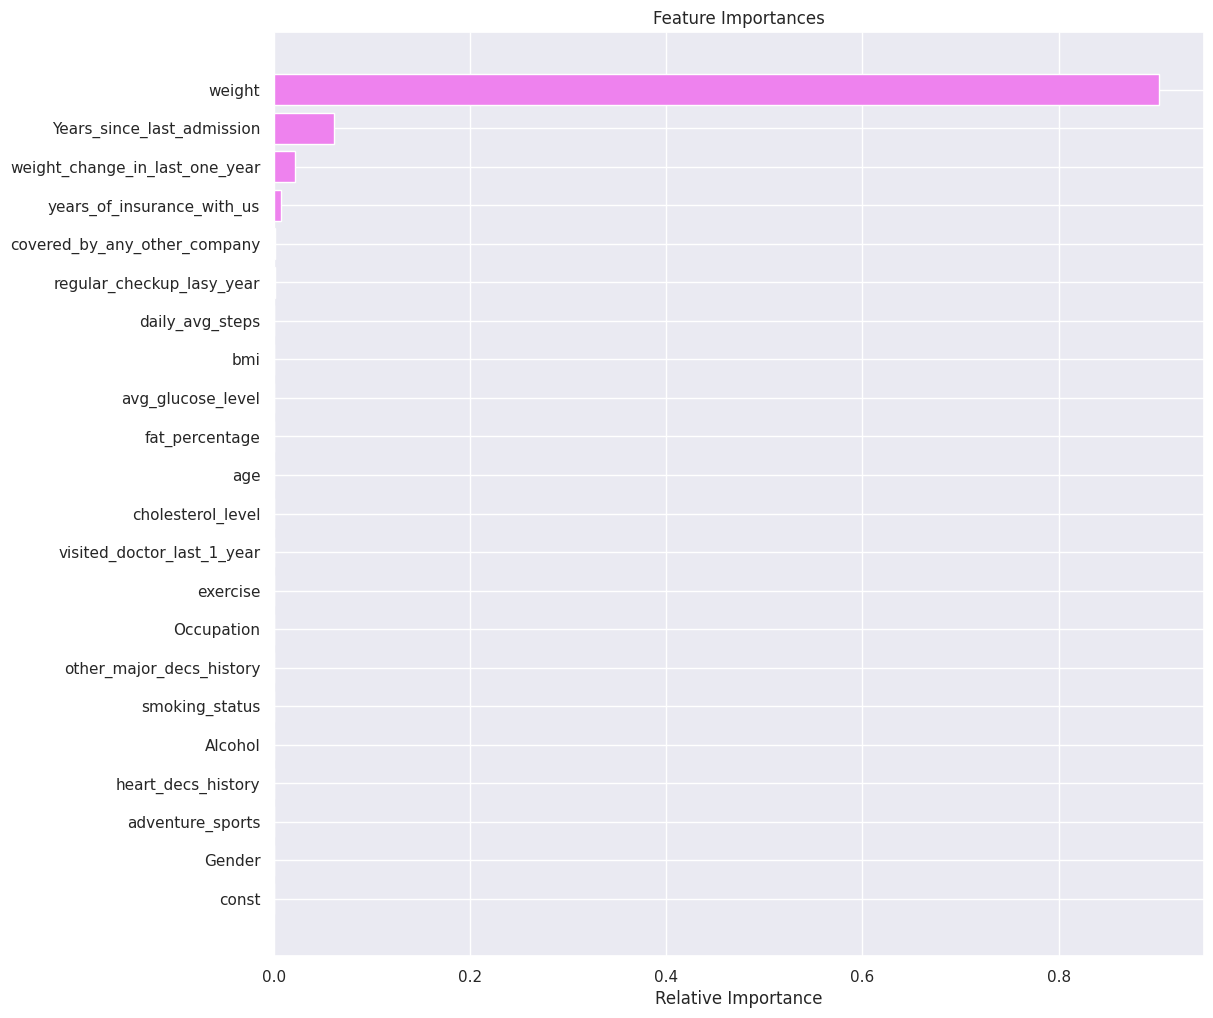

In [ ]:
feature_names = x_train.columns
importances = gb_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

####**Observations on Feature Importance (Tuned Gradient Boosting Model)**
- Dominant Feature:
    - Weight is the most influential feature with an importance score of 0.902, indicating it has a significant impact on model predictions. This heavy reliance suggests that weight alone contributes disproportionately to the outcome.
- Moderately Important Features:
    - Years Since Last Admission (0.061) and Weight Change in Last One Year (0.021) are the next most impactful variables, indicating some influence on the target variable.
- Minor Contributions:
    - Features such as Years of Insurance with Us, Covered by Any Other Company, and Regular Checkup Last Year have minimal influence, each scoring less than 0.01.
    - Many features like Alcohol, Heart Disease History, and Adventure Sports contribute almost negligibly (close to zero).


### XgBoosting Regressor

In [ ]:
xgb_estimator = XGBRegressor(random_state=1, enable_categorical=True, verbosity=0)

In [ ]:
# Train model
xgb_estimator.fit(x_train,y_train)

# Predictions
y_train_pred = xgb_estimator.predict(x_train)  # Predictions for training set
y_test_pred = xgb_estimator.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
XGB_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
XGB_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", XGB_Train)
print("\n🔹 Test Set Metrics:", XGB_Test)


🔹 Training Set Metrics: {'R²': 0.978, 'Adj. R²': 0.978, 'RMSE': 0.1, 'MAE': 0.07, 'MAPE (%)': 0.75}

🔹 Test Set Metrics: {'R²': 0.9446, 'Adj. R²': 0.9445, 'RMSE': 0.15, 'MAE': 0.11, 'MAPE (%)': 1.17}


**Observation on Tuned Gradient Boosting Model Performance**
- Training Set Analysis:

   - The model exhibits excellent performance on the training data with an R² of 0.978, indicating it explains 97.8% of the variance in the target variable.
   - RMSE (0.1) and MAE (0.07) are notably low, suggesting minimal prediction errors.
  -  The MAPE of 0.75% confirms strong predictive accuracy for percentage-based errors.
 - Test Set Analysis:

   - The test performance shows a slight decline with an R² of 0.9446, still indicating strong generalization.
   - RMSE (0.15) and MAE (0.11) are slightly higher than in training but remain within an acceptable range.
   - MAPE of 1.17% reflects that the model maintains a high degree of accuracy on unseen data.

In [ ]:
# importance of features in the tree building

print(pd.DataFrame(xgb_estimator.feature_importances_, columns = ["Imp"], index = x_train.columns).sort_values(by = 'Imp', ascending = False))

                                    Imp
weight                         0.872782
Years_since_last_admission     0.026726
weight_change_in_last_one_year 0.025971
covered_by_any_other_company   0.009389
regular_checkup_lasy_year      0.005512
Alcohol                        0.004625
fat_percentage                 0.004608
other_major_decs_history       0.004549
exercise                       0.004083
cholesterol_level              0.004029
bmi                            0.003920
daily_avg_steps                0.003891
smoking_status                 0.003496
avg_glucose_level              0.003483
age                            0.003449
Gender                         0.003356
years_of_insurance_with_us     0.003345
Occupation                     0.003243
heart_decs_history             0.003235
visited_doctor_last_1_year     0.003183
adventure_sports               0.003126
const                          0.000000


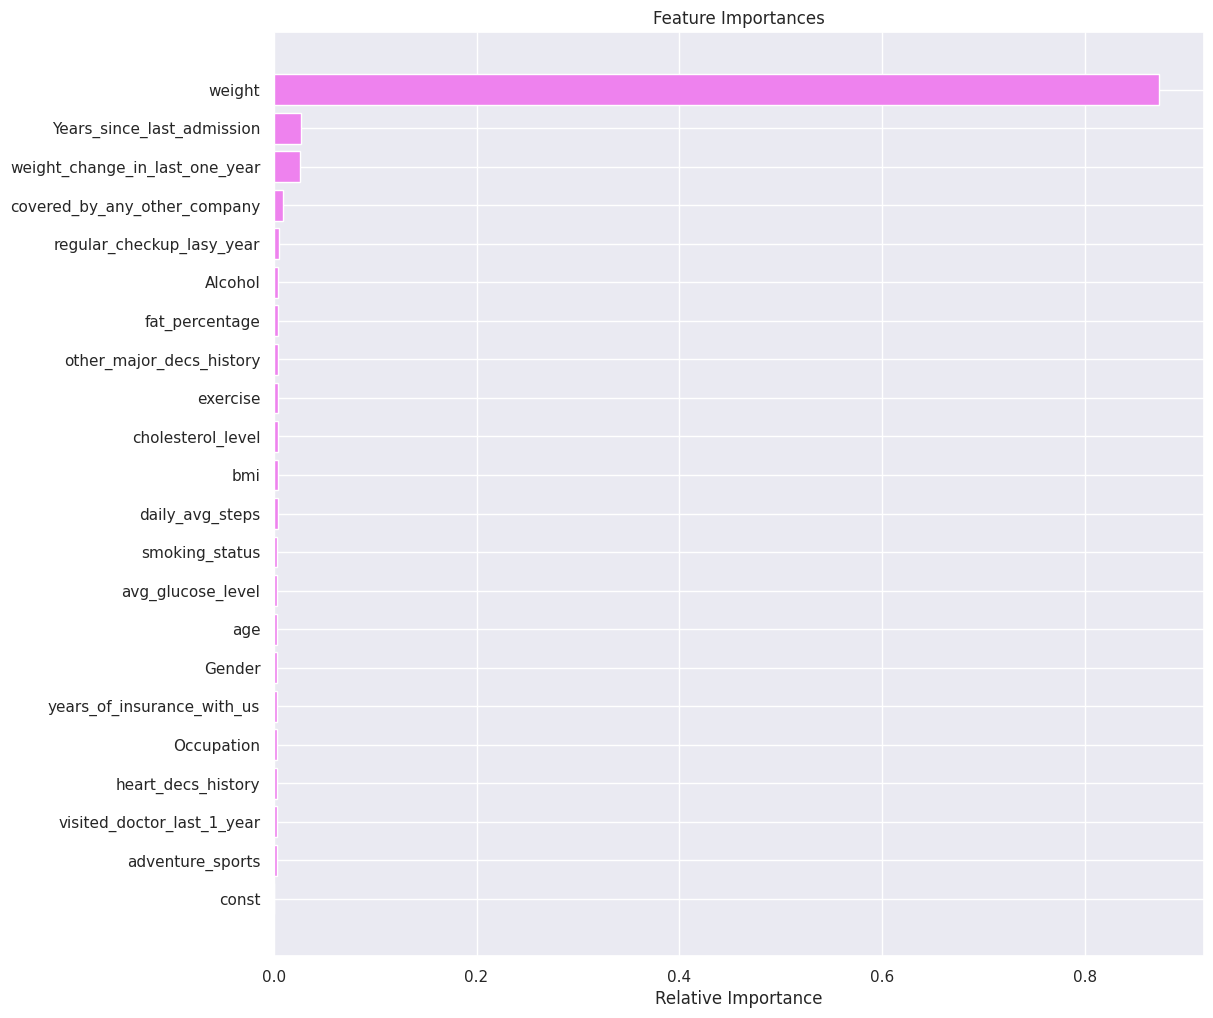

In [ ]:
feature_names = x_train.columns
importances = xgb_estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

####**Observation on Feature Importance (Tuned XG Boosting Model)**
1.	Dominance of 'Weight':
    - The feature weight holds the highest importance at 0.8727, making it the primary driver of model predictions. This suggests that customer weight significantly influences the target variable.
2.	Secondary Important Features:
    - Features like Years_since_last_admission (0.0267) and weight_change_in_last_one_year (0.0260) provide moderate contribution, indicating their role in shaping outcomes but with considerably less influence than weight.
3.	Minor Contributors:
    - Features such as covered_by_any_other_company, Alcohol, cholesterol_level, and smoking_status contribute marginally, suggesting they may offer minor predictive value.
4.	Even Distribution in Lower Importance Features:
    - Features like adventure_sports, heart_decs_history, and visited_doctor_last_1_year have very low importance scores (around 0.003), indicating limited impact.


In [ ]:
# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=1,enable_categorical=True, verbosity = 0)

# Grid of parameters to choose from
parameters = {'n_estimators': [75,100,125,150],
              'subsample':[0.7, 0.8, 0.9, 1],
              'gamma':[0, 1, 3, 5],
              'colsample_bytree':[0.7, 0.8, 0.9, 1],
              'colsample_bylevel':[0.7, 0.8, 0.9, 1]
              }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

In [ ]:
# Fit the best algorithm to the data.
xgb_tuned.fit(x_train, y_train)

# Predictions
y_train_pred = xgb_tuned.predict(x_train)  # Predictions for training set
y_test_pred = xgb_tuned.predict(x_test)  # Predictions for test set

# Number of samples and features
n_train, p = x_train.shape  # Training data: n = samples, p = features
n_test = x_test.shape[0]  # Test data: n = samples

# Function to calculate Adjusted R-squared
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Performance Metrics for Training Set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
adj_r2_train = adjusted_r2(r2_train, n_train, p)
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

# Performance Metrics for Test Set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
adj_r2_test = adjusted_r2(r2_test, n_test, p)
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100


# Store Training Set Results
XGB_Tuned_Train = {
    "R²": round(r2_train, 4),
    "Adj. R²": round(adj_r2_train, 4),
    "RMSE": round(rmse_train, 2),
    "MAE": round(mae_train, 2),
    "MAPE (%)": round(mape_train, 2)
}

# Store Test Set Results
XGB_Tuned_Test = {
    "R²": round(r2_test, 4),
    "Adj. R²": round(adj_r2_test, 4),
    "RMSE": round(rmse_test, 2),
    "MAE": round(mae_test, 2),
    "MAPE (%)": round(mape_test, 2)
}

# To view results, just call:
print("\n🔹 Training Set Metrics:", XGB_Tuned_Train)
print("\n🔹 Test Set Metrics:", XGB_Tuned_Test)


🔹 Training Set Metrics: {'R²': 0.9494, 'Adj. R²': 0.9493, 'RMSE': 0.15, 'MAE': 0.11, 'MAPE (%)': 1.14}

🔹 Test Set Metrics: {'R²': 0.9486, 'Adj. R²': 0.9485, 'RMSE': 0.15, 'MAE': 0.11, 'MAPE (%)': 1.14}


####**Observation on Tuned XG Boost Model Performance:**
- Training Set Metrics:
  - The model demonstrates strong performance with an R² = 0.9494, indicating it explains approximately 94.94% of the variance in the training data.
  -	Error metrics are low, with an RMSE = 0.15, MAE = 0.11, and MAPE = 1.14%, reflecting solid prediction accuracy.
- Test Set Metrics:
  -	The model maintains consistent performance on the test set with an R² = 0.9486, showing minimal overfitting.
  - The error metrics remain stable across train and test sets, with RMSE, MAE, and MAPE values closely aligned.
-	Model Stability:
  -	The negligible performance gap between training and test metrics highlights a well-generalized model that effectively balances bias and variance.


In [ ]:
# importance of features in the tree building

print(pd.DataFrame(xgb_tuned.feature_importances_, columns = ["Imp"], index = x_train.columns).sort_values(by = 'Imp', ascending = False))

                                    Imp
weight                         0.914701
weight_change_in_last_one_year 0.033567
Years_since_last_admission     0.027917
regular_checkup_lasy_year      0.008142
covered_by_any_other_company   0.007921
years_of_insurance_with_us     0.007753
avg_glucose_level              0.000000
fat_percentage                 0.000000
exercise                       0.000000
Alcohol                        0.000000
smoking_status                 0.000000
bmi                            0.000000
const                          0.000000
other_major_decs_history       0.000000
heart_decs_history             0.000000
age                            0.000000
daily_avg_steps                0.000000
cholesterol_level              0.000000
visited_doctor_last_1_year     0.000000
Occupation                     0.000000
adventure_sports               0.000000
Gender                         0.000000


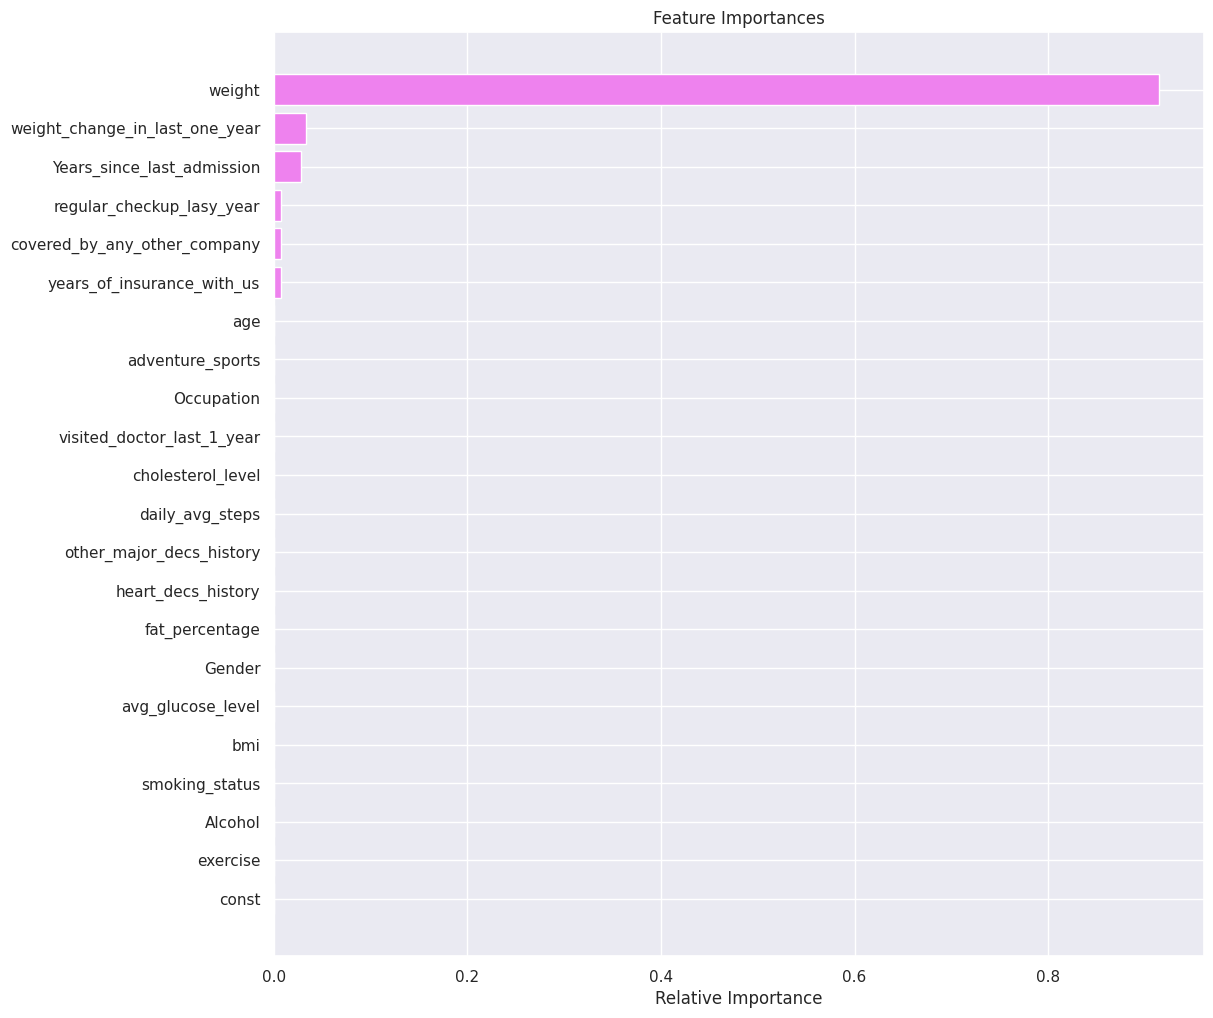

In [ ]:
feature_names = x_train.columns
importances = xgb_tuned.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

####**Key Observations:**
- Dominating Variable:
    - weight has an overwhelming importance score of 0.9147, indicating that this single feature drives most of the model's predictions.
    - Such heavy reliance on one feature suggests potential data imbalance, model bias, or overfitting.
-	Moderate Importance Features:
    - weight_change_in_last_one_year (0.0336)
    - Years_since_last_admission (0.0279)
    - These features contribute some predictive value but are significantly less impactful than weight.
-	Low/Zero Importance Features:
    -	Several meaningful variables like avg_glucose_level, bmi, exercise, and smoking_status have zero importance, which is unexpected given their potential relevance in healthcare data


# Model Comparison

In [ ]:
# Convert each dictionary to a DataFrame before transposing
models_train_comp_df = pd.concat([
    pd.DataFrame(Linear_regression_Train, index=["Linear Regression train"]).T,
    pd.DataFrame(Dtree_Train, index=["Dtree train"]).T,
    pd.DataFrame(Dtree_Estimator_Train, index=["Tuned Dtree train"]).T,
    pd.DataFrame(Bagging_Train, index=["Bagging train"]).T,
    pd.DataFrame(Bagging_Estimator_Train, index=["Tuned Bagging train"]).T,
    pd.DataFrame(RF_Train, index=["RF train"]).T,
    pd.DataFrame(RF_Estimator_Train, index=["Tuned RF train"]).T,
    pd.DataFrame(AdaBoost_Train, index=["Ada Boost train"]).T,
    pd.DataFrame(AdaBoost_Estimator_Train, index=["Tuned Ada Boost train"]).T,
    pd.DataFrame(GB_Train, index=["Gradient Boost train"]).T,
    pd.DataFrame(GB_Tuned_Train, index=["Tuned Gradient Boost train"]).T,
    pd.DataFrame(XGB_Train, index=["XGBoost train"]).T,
    pd.DataFrame(XGB_Tuned_Train, index=["Tuned XGBoost train"]).T,
], axis=1)

# Print the comparison DataFrame
print("Train Validation Performance Comparison:")
print(models_train_comp_df)


Train Validation Performance Comparison:
          Linear Regression train  Dtree train  Tuned Dtree train  \
R²                       0.880300     1.000000           0.709300   
Adj. R²                  0.880300     1.000000           0.708900   
RMSE                     0.230000     0.000000           0.360000   
MAE                      0.180000     0.000000           0.290000   
MAPE (%)                 1.820000     0.000000           2.910000   

          Bagging train  Tuned Bagging train  RF train  Tuned RF train  \
R²             0.990000             0.991200  0.992600        0.986900   
Adj. R²        0.990000             0.991200  0.992600        0.986900   
RMSE           0.070000             0.060000  0.060000        0.080000   
MAE            0.040000             0.050000  0.040000        0.060000   
MAPE (%)       0.460000             0.470000  0.430000        0.570000   

          Ada Boost train  Tuned Ada Boost train  Gradient Boost train  \
R²               0.933300

In [ ]:
# Convert each dictionary to a DataFrame (with column names)
models_test_comp_df = pd.concat([
    pd.DataFrame(Linear_regression_Test, index=["Linear Regression test"]).T,
    pd.DataFrame(Dtree_Test, index=["DTree test"]).T,
    pd.DataFrame(Dtree_Estimator_Test, index=["Tuned DTree test"]).T,
    pd.DataFrame(Bagging_Test, index=["Bagging test"]).T,
    pd.DataFrame(Bagging_Estimator_Test, index=["Tuned Bagging test"]).T,
    pd.DataFrame(RF_Test, index=["RF test"]).T,
    pd.DataFrame(RF_Estimator_Test, index=["Tuned RF test"]).T,
    pd.DataFrame(AdaBoost_Test, index=["Ada Boost test"]).T,
    pd.DataFrame(AdaBoost_Estimator_Test, index=["Tuned Ada Boost test"]).T,
    pd.DataFrame(GB_Test, index=["Gradient Boost test"]).T,
    pd.DataFrame(GB_Tuned_Test, index=["Tuned Gradient Boost test"]).T,
    pd.DataFrame(XGB_Test, index=["XGBoost test"]).T,
    pd.DataFrame(XGB_Tuned_Test, index=["Tuned XGBoost test"]).T,
], axis=1)

# Print the comparison DataFrame
print("Test Validation Performance Comparison:")
print(models_test_comp_df)

Test Validation Performance Comparison:
          Linear Regression test  DTree test  Tuned DTree test  Bagging test  \
R²                      0.883200    0.892300          0.696600      0.940400   
Adj. R²                 0.883000    0.892000          0.695700      0.940300   
RMSE                    0.220000    0.210000          0.360000      0.160000   
MAE                     0.170000    0.150000          0.290000      0.120000   
MAPE (%)                1.780000    1.570000          2.930000      1.210000   

          Tuned Bagging test  RF test  Tuned RF test  Ada Boost test  \
R²                  0.941900 0.945900       0.947400        0.933300   
Adj. R²             0.941700 0.945800       0.947200        0.933100   
RMSE                0.160000 0.150000       0.150000        0.170000   
MAE                 0.120000 0.110000       0.110000        0.130000   
MAPE (%)            1.210000 1.150000       1.140000        1.320000   

          Tuned Ada Boost test  Gradient Boost

#### **Model Selection:**
-	**Tuned Bagging Regressor** uses all variables effectively, which might be appealing. But the **Tuned Bagging Regressor** has the highest train R² (0.9912), but its test R² (0.9419) is the lowest among the models. Which suggests it overfits the training data and generalizes less effectively to unseen data.
-	**Tuned Gradient Boost** and **Tuned XG Boost** remove less relevant features, leading to more efficient models.

**Tuned Gradient Boosting** is the best choice because:
-	Highest Test R² (0.9490) --> Best generalization.
-	Lowest Test MAPE (1.13%) --> More reliable predictions.
-	Balances feature selection and performance well.
-	Lower overfitting risk compared to Tuned Bagging Regressor.